<div style="background: linear-gradient(135deg, #0f0c29, #302b63, #24243e); padding: 40px 30px; border-radius: 16px; margin-bottom: 30px; color: white; font-family: 'Segoe UI', Arial, sans-serif;">
  <h1 style="font-size: 2.8em; margin: 0 0 10px 0; letter-spacing: -1px;">🧠 Sequence Models: Zero to Hero</h1>
  <h2 style="font-size: 1.4em; font-weight: 400; margin: 0 0 20px 0; color: #b8b5ff;">RNN → LSTM → GRU → WaveNet — A Gentle, Complete Introduction</h2>
  <hr style="border: 1px solid rgba(255,255,255,0.2); margin: 20px 0;">
  <p style="font-size: 1.05em; line-height: 1.7; color: #ddd;">Inspired by Aurélien Géron's <em>Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow</em> (O'Reilly), this notebook takes you from <strong>zero knowledge of sequence models</strong> to a deep, working understanding of recurrent and convolutional sequence architectures — all in <strong>PyTorch</strong>.</p>
  <div style="display: flex; gap: 30px; margin-top: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.08); padding: 12px 20px; border-radius: 10px; flex: 1; min-width: 160px;">
      <div style="font-size: 0.8em; color: #a5a2ff; text-transform: uppercase; letter-spacing: 1px;">Course</div>
      <div style="font-size: 1.1em; margin-top: 4px;">CMPE 258 — Deep Learning</div>
    </div>
    <div style="background: rgba(255,255,255,0.08); padding: 12px 20px; border-radius: 10px; flex: 1; min-width: 160px;">
      <div style="font-size: 0.8em; color: #a5a2ff; text-transform: uppercase; letter-spacing: 1px;">Framework</div>
      <div style="font-size: 1.1em; margin-top: 4px;">PyTorch 2.x</div>
    </div>
    <div style="background: rgba(255,255,255,0.08); padding: 12px 20px; border-radius: 10px; flex: 1; min-width: 160px;">
      <div style="font-size: 0.8em; color: #a5a2ff; text-transform: uppercase; letter-spacing: 1px;">Semester</div>
      <div style="font-size: 1.1em; margin-top: 4px;">Spring 2026</div>
    </div>
  </div>
</div>

<div style="background: #f8f9fa; border-left: 5px solid #6c5ce7; padding: 25px 30px; border-radius: 0 12px 12px 0; margin-bottom: 30px; font-family: 'Segoe UI', Arial, sans-serif;">
  <h2 style="margin: 0 0 15px 0; color: #2d3436;">📑 Table of Contents</h2>
  <ol style="font-size: 1.05em; line-height: 2.2; color: #2d3436; padding-left: 20px;">
    <li><a href="#part1" style="color: #6c5ce7; text-decoration: none;"><strong>The World of Sequences</strong></a> — Why order matters, sequence data pipeline</li>
    <li><a href="#part2" style="color: #6c5ce7; text-decoration: none;"><strong>Vanilla RNN</strong></a> — The simplest recurrent network</li>
    <li><a href="#part3" style="color: #6c5ce7; text-decoration: none;"><strong>LSTM</strong></a> — Long Short-Term Memory, solving the vanishing gradient</li>
    <li><a href="#part4" style="color: #6c5ce7; text-decoration: none;"><strong>GRU</strong></a> — Gated Recurrent Unit, the elegant alternative</li>
    <li><a href="#part5" style="color: #6c5ce7; text-decoration: none;"><strong>Deep RNNs & Practical Tricks</strong></a> — Stacking, dropout, bidirectional, gradient clipping</li>
    <li><a href="#part6" style="color: #6c5ce7; text-decoration: none;"><strong>WaveNet</strong></a> — Causal & dilated convolutions for sequences</li>
    <li><a href="#part7" style="color: #6c5ce7; text-decoration: none;"><strong>Grand Comparison & Takeaways</strong></a> — Benchmarks, when to use what, further reading</li>
  </ol>
</div>

<div style="background: #fff3cd; border: 1px solid #ffc107; padding: 15px 20px; border-radius: 10px; margin-bottom: 20px; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>⚡ How to Use This Notebook</strong><br>
  Run each cell top-to-bottom. Every section builds on the previous one. If you're on <strong>Google Colab</strong>, go to <code>Runtime → Change runtime type → GPU</code> for faster training (though CPU works fine for our dataset sizes).
</div>

In [ ]:
# ============================================================================
# SETUP — Install & Import Everything We Need
# ============================================================================
# On Colab, PyTorch is pre-installed. We just need matplotlib for plots.
# If running locally, install PyTorch from https://pytorch.org/get-started
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
import time
import math
import warnings
warnings.filterwarnings('ignore')

# --------------------------------------------------------------------------
# Reproducibility: fix all random seeds so results are deterministic
# --------------------------------------------------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --------------------------------------------------------------------------
# Device selection: use GPU if available, else CPU
# --------------------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.10.0+cu128
Device          : cuda
CUDA available  : True
GPU             : Tesla T4


In [ ]:
# ============================================================================
# PLOTTING DEFAULTS — Consistent, publication-quality figures
# ============================================================================

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Color palette we'll reuse throughout the notebook
COLORS = {
    'rnn':     '#e74c3c',   # Red
    'lstm':    '#3498db',   # Blue
    'gru':     '#2ecc71',   # Green
    'wavenet': '#9b59b6',   # Purple
}

print("✓ Plotting defaults configured")

✓ Plotting defaults configured


<a id="part1"></a>
<div style="background: linear-gradient(135deg, #e74c3c, #c0392b); padding: 25px 30px; border-radius: 14px; margin: 40px 0 20px 0; color: white; font-family: 'Segoe UI', Arial, sans-serif;">
  <h1 style="margin: 0; font-size: 2em;">Part 1: The World of Sequences</h1>
  <p style="margin: 10px 0 0 0; font-size: 1.1em; opacity: 0.9;">Why order matters — and how to feed sequential data to neural networks</p>
</div>

<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #e74c3c; padding-bottom: 8px;">🤔 What Makes Sequence Data Special?</h2>

<p>Think about the difference between a <strong>photo</strong> and a <strong>sentence</strong>:</p>

<table style="width:100%; border-collapse: collapse; margin: 15px 0;">
  <tr style="background: #f1f2f6;">
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">Non-Sequential (Image)</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">Sequential (Text)</th>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Shuffle the pixels → still recognizable (locally)</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Shuffle the words → <em>"dog the bit man the"</em> 🤷</td>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Each pixel is independent of position (in theory)</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Each word depends on what came before</td>
  </tr>
  <tr>
    <td style="padding: 12px;">Fixed input size (e.g., 224×224)</td>
    <td style="padding: 12px;">Variable length (3 words or 3,000 words)</td>
  </tr>
</table>

<p><strong>The key insight:</strong> In sequential data, <em>the order carries meaning</em>. The same elements in a different order produce completely different meanings. This is why we need specialized architectures.</p>

<h3 style="color: #2d3436; margin-top: 25px;">📋 Examples of Sequence Data</h3>
<ul>
  <li><strong>Text:</strong> sentences, documents, code — each token depends on context</li>
  <li><strong>Time series:</strong> stock prices, weather, sensor readings — past values predict future</li>
  <li><strong>Audio:</strong> speech waveforms, music — temporal patterns at multiple scales</li>
  <li><strong>Video:</strong> sequences of frames — motion requires temporal understanding</li>
  <li><strong>DNA:</strong> nucleotide sequences — position determines gene function</li>
  <li><strong>User behavior:</strong> click streams, purchase history — actions form patterns over time</li>
</ul>

<h3 style="color: #2d3436; margin-top: 25px;">🧩 The Core Challenge</h3>
<p>A standard feedforward network takes a <strong>fixed-size input</strong> and maps it to a <strong>fixed-size output</strong>. But sequences are:</p>
<ol>
  <li><strong>Variable length</strong> — a tweet ≠ a novel</li>
  <li><strong>Order-dependent</strong> — shuffling destroys meaning</li>
  <li><strong>Context-sensitive</strong> — understanding position 100 may require remembering position 1</li>
</ol>
<p>We need architectures that can <em>remember</em> what they've seen and <em>process inputs one step at a time</em>. That's exactly what RNNs do — and what we'll build in this notebook.</p>

</div>

<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #e74c3c; padding-bottom: 8px;">📖 Our Task: Character-Level Language Modeling</h2>

<p>Throughout this notebook we'll tackle <strong>one consistent task</strong> across all four architectures so we can fairly compare them:</p>

<div style="background: #dfe6e9; padding: 20px; border-radius: 10px; margin: 15px 0; text-align: center; font-size: 1.15em;">
  <strong>Given a sequence of characters, predict the next character.</strong>
</div>

<p>This is the same task Andrej Karpathy used in his famous <em>"The Unreasonable Effectiveness of Recurrent Neural Networks"</em> blog post. It's deceptively simple but reveals deep differences between architectures:</p>

<ul>
  <li>Input: <code>"The cat sat on the "</code></li>
  <li>Model predicts the probability distribution over the next character</li>
  <li>Target: <code>"m"</code> (for "mat", say)</li>
</ul>

<p>We'll use a text corpus, convert characters to integers, and train each model to predict the next character. Then we can <strong>generate text</strong> by sampling from the model's predictions — a fun way to evaluate whether the model has learned the structure of the language.</p>

<h3 style="color: #2d3436; margin-top: 25px;">Why Character-Level?</h3>
<p>Word-level models need large vocabularies and embeddings. Character-level models have tiny vocabularies (just ~65 unique characters for English text), which means:</p>
<ul>
  <li>✅ Models are <strong>small and fast</strong> to train</li>
  <li>✅ We can <strong>see every detail</strong> of what the model learns</li>
  <li>✅ The model must learn spelling, grammar, and structure <strong>from scratch</strong></li>
  <li>✅ Perfect for comparing architectures on a level playing field</li>
</ul>

</div>

<div style="background: #e8f8f5; border-left: 5px solid #1abc9c; padding: 15px 20px; border-radius: 0 10px 10px 0; margin: 15px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>🔧 Step 1:</strong> Let's download a text corpus and build our character-level vocabulary.
</div>

In [ ]:
# ============================================================================
# TEXT CORPUS — We'll use a small, self-contained text for reproducibility
# ============================================================================
# Instead of downloading externally, we define a rich text corpus inline.
# This is a collection of simple English prose with enough structure for
# our models to learn character patterns, word boundaries, and basic grammar.
# ============================================================================

TEXT_CORPUS = """
The sun rose over the mountains, casting long shadows across the valley below.
Birds began to sing their morning songs, filling the air with melodies that
echoed through the trees. The river wound its way through the landscape,
sparkling in the golden light of dawn.

In the small village at the foot of the mountains, people were beginning to
stir. The baker had already been at work for hours, kneading dough and stoking
the fires of the great stone oven. The smell of fresh bread drifted through
the narrow streets, drawing sleepy villagers from their homes.

The old man sat on the porch of his cottage, watching the world wake up around
him. He had lived in this village all his life, and every morning still felt
like a gift. The mountains never changed, yet they were different every day,
their peaks painted in new colors by the shifting light.

Down by the river, children were already playing, splashing in the shallow
water and chasing fish that darted between the stones. Their laughter carried
on the breeze, mixing with the sounds of the waking village.

The schoolteacher walked along the path to the schoolhouse, her books tucked
under her arm. She loved these quiet morning walks, the time before the day
filled with the noise and energy of her students. Teaching was her calling,
and she approached each day with renewed purpose and enthusiasm.

In the market square, merchants were setting up their stalls, arranging fruits
and vegetables in colorful displays. The farmer brought his fresh produce from
the fields, still wet with morning dew. Trade was the lifeblood of the village,
connecting it to the wider world beyond the mountains.

The blacksmith hammered at his forge, shaping metal with practiced hands. Each
strike sent sparks flying into the cool morning air. He was making a new set of
tools for the carpenter, who needed them to build the new bridge across the
river. Cooperation was the foundation of village life.

As the morning wore on, the village came fully alive. Dogs barked, horses
neighed, and the sound of conversation filled every corner. The mayor stood
at the center of the square, discussing plans for the upcoming harvest festival
with a group of eager villagers.

The harvest festival was the highlight of the year. Everyone contributed
something, from the finest wines to the most elaborate decorations. Music would
fill the air for three days and nights, and people would come from neighboring
villages to join in the celebration.

The young apprentice watched the master craftsman work with fascination. Every
movement was precise, every decision deliberate. Learning a trade was not just
about skill, the master explained, it was about understanding the materials,
respecting the process, and finding beauty in the work itself.

The library stood at the edge of the village, a quiet sanctuary of knowledge
and wisdom. Its shelves held books collected over generations, each one a
window into another world, another time, another way of thinking. The librarian
tended to the collection with great care, preserving the past for the future.

As evening approached, the sky turned shades of orange and purple. The
mountains caught the last rays of sunlight, glowing like embers against the
darkening sky. One by one, lanterns were lit along the streets, and the village
settled into the peaceful rhythm of night.

The stars emerged, countless and bright, scattered across the vast darkness
above. The old man still sat on his porch, now gazing upward at the familiar
constellations. Tomorrow would bring another day, another dawn, another chance
to witness the endless beauty of this simple life in the mountains.
""".strip()

print(f"Corpus length      : {len(TEXT_CORPUS):,} characters")
print(f"First 200 chars    : {TEXT_CORPUS[:200]}...")

Corpus length      : 3,662 characters
First 200 chars    : The sun rose over the mountains, casting long shadows across the valley below.
Birds began to sing their morning songs, filling the air with melodies that
echoed through the trees. The river wound its...


In [ ]:
# ============================================================================
# CHARACTER VOCABULARY — Map each unique character to an integer and back
# ============================================================================
# In character-level modeling, the "vocabulary" is every unique character in
# the text. We sort them for deterministic ordering, then create two lookup
# dictionaries:
#   - char_to_idx: 'a' → 5   (for encoding input)
#   - idx_to_char: 5 → 'a'   (for decoding output)
# ============================================================================

# Get sorted list of unique characters
chars = sorted(set(TEXT_CORPUS))
vocab_size = len(chars)

# Create bidirectional mappings
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"Vocabulary size    : {vocab_size} unique characters")
print(f"Characters         : {''.join(chars)}")
print()

# Show the mapping for a few example characters
print("Example mappings:")
for ch in ['a', 'z', 'A', ' ', '.', '\n']:
    if ch in char_to_idx:
        display_ch = repr(ch) if ch in ('\n', ' ') else ch
        print(f"  {display_ch:6s} → {char_to_idx[ch]}")

Vocabulary size    : 42 unique characters
Characters         : 
 ,.ABCDEHILMOSTabcdefghijklmnopqrstuvwxyz

Example mappings:
  a      → 16
  z      → 41
  A      → 4
  ' '    → 1
  .      → 3
  '\n'   → 0


In [ ]:
# ============================================================================
# ENCODE THE ENTIRE TEXT — Convert characters to a tensor of integers
# ============================================================================
# This is the numerical representation that PyTorch will work with.
# Each character becomes its vocabulary index.
#
# "The" → [40, 17, 14]  (T=40, h=17, e=14, for example)
# ============================================================================

data = torch.tensor([char_to_idx[ch] for ch in TEXT_CORPUS], dtype=torch.long)

print(f"Encoded tensor shape : {data.shape}")
print(f"Encoded tensor dtype : {data.dtype}")
print(f"First 50 values      : {data[:50].tolist()}")
print(f"Decoded back         : {''.join(idx_to_char[i.item()] for i in data[:50])}")

Encoded tensor shape : torch.Size([3662])
Encoded tensor dtype : torch.int64
First 50 values      : [15, 23, 20, 1, 34, 36, 29, 1, 33, 30, 34, 20, 1, 30, 37, 20, 33, 1, 35, 23, 20, 1, 28, 30, 36, 29, 35, 16, 24, 29, 34, 2, 1, 18, 16, 34, 35, 24, 29, 22, 1, 27, 30, 29, 22, 1, 34, 23, 16, 19]
Decoded back         : The sun rose over the mountains, casting long shad


<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #e74c3c; padding-bottom: 8px;">🪟 Sliding Window: Creating Training Examples</h2>

<p>To train a model to predict the next character, we create <strong>input-target pairs</strong> using a <em>sliding window</em> over the text:</p>

<pre style="background: #2d3436; color: #dfe6e9; padding: 20px; border-radius: 8px; font-size: 1.05em; overflow-x: auto;">
Text:    T  h  e     c  a  t     s  a  t     o  n     t  h  e     m  a  t
         ─────────────────────────────────────────────────────────────────
Window 1:  [T  h  e     c  a  t     s]  →  target: a
Window 2:  [h  e     c  a  t     s  a]  →  target: t
Window 3:  [e     c  a  t     s  a  t]  →  target:  
Window 4:  [   c  a  t     s  a  t   ]  →  target: o
           ...and so on...
</pre>

<p>The <strong>sequence length</strong> (window size) is a hyperparameter. Longer windows give the model more context but cost more memory. We'll use <code>SEQ_LENGTH = 64</code> characters — long enough to capture word-level and phrase-level patterns.</p>

</div>

In [ ]:
# ============================================================================
# DATASET CLASS — PyTorch Dataset for character-level sequences
# ============================================================================
# This is the standard PyTorch pattern: subclass torch.utils.data.Dataset,
# implement __len__ and __getitem__. The DataLoader will handle batching,
# shuffling, and parallel loading for us.
#
# For each index i, we return:
#   x = data[i : i + seq_length]       ← the input sequence
#   y = data[i + 1 : i + seq_length + 1]  ← shifted by 1 (the targets)
#
# Note: y is a SEQUENCE of targets, not a single target. This means for a
# single training example, the model predicts the next character at EVERY
# position in the sequence. This is much more efficient than predicting
# only the last character.
# ============================================================================

class CharDataset(Dataset):
    """Character-level dataset with sliding window.

    Args:
        text_data: 1D tensor of encoded characters (integers)
        seq_length: number of characters in each input sequence

    Returns:
        (input_seq, target_seq) — both of shape (seq_length,)
    """
    def __init__(self, text_data: torch.Tensor, seq_length: int):
        self.data = text_data
        self.seq_length = seq_length

    def __len__(self) -> int:
        # Number of valid windows we can extract
        return len(self.data) - self.seq_length

    def __getitem__(self, idx: int):
        # Input:  characters at positions [idx, idx+seq_length)
        x = self.data[idx : idx + self.seq_length]
        # Target: characters at positions [idx+1, idx+seq_length+1)
        # i.e., the "next character" for each position in x
        y = self.data[idx + 1 : idx + self.seq_length + 1]
        return x, y


# ============================================================================
# HYPERPARAMETERS — Shared across all models for fair comparison
# ============================================================================

SEQ_LENGTH  = 64      # Characters per input sequence (the "context window")
BATCH_SIZE  = 64      # Number of sequences per training batch
EMBED_DIM   = 64      # Dimensionality of character embeddings
HIDDEN_DIM  = 128     # Hidden state size for RNN/LSTM/GRU
NUM_EPOCHS  = 20      # Training epochs (kept small for Colab speed)
LR          = 0.003   # Learning rate for Adam optimizer

print(f"SEQ_LENGTH  = {SEQ_LENGTH}")
print(f"BATCH_SIZE  = {BATCH_SIZE}")
print(f"EMBED_DIM   = {EMBED_DIM}")
print(f"HIDDEN_DIM  = {HIDDEN_DIM}")
print(f"NUM_EPOCHS  = {NUM_EPOCHS}")
print(f"LR          = {LR}")

SEQ_LENGTH  = 64
BATCH_SIZE  = 64
EMBED_DIM   = 64
HIDDEN_DIM  = 128
NUM_EPOCHS  = 20
LR          = 0.003


In [ ]:
# ============================================================================
# TRAIN / VALIDATION SPLIT — 90% train, 10% validation
# ============================================================================
# We split the text sequentially (not randomly!) because the text has
# structure that we want to preserve. The model trains on the first 90%
# and we evaluate on the last 10% — text it has never seen.
# ============================================================================

split_idx = int(len(data) * 0.9)

train_data = data[:split_idx]
val_data   = data[split_idx:]

train_dataset = CharDataset(train_data, SEQ_LENGTH)
val_dataset   = CharDataset(val_data,   SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"Training characters  : {len(train_data):,}")
print(f"Validation characters: {len(val_data):,}")
print(f"Training examples    : {len(train_dataset):,}")
print(f"Validation examples  : {len(val_dataset):,}")
print(f"Training batches     : {len(train_loader)}")
print(f"Validation batches   : {len(val_loader)}")

Training characters  : 3,295
Validation characters: 367
Training examples    : 3,231
Validation examples  : 303
Training batches     : 50
Validation batches   : 4


In [ ]:
# ============================================================================
# INSPECT A BATCH — Verify the data pipeline is working correctly
# ============================================================================

x_batch, y_batch = next(iter(train_loader))
print(f"Input batch shape  : {x_batch.shape}   (batch_size × seq_length)")
print(f"Target batch shape : {y_batch.shape}   (batch_size × seq_length)")
print()

# Show one example: input sequence and its corresponding targets
example_input  = ''.join(idx_to_char[i.item()] for i in x_batch[0])
example_target = ''.join(idx_to_char[i.item()] for i in y_batch[0])
print(f"Example input  : {repr(example_input)}")
print(f"Example target : {repr(example_target)}")
print()
print("Notice: the target is the input shifted by one character to the right.")
print("Each position in the input has a corresponding 'next character' target.")

Input batch shape  : torch.Size([64, 64])   (batch_size × seq_length)
Target batch shape : torch.Size([64, 64])   (batch_size × seq_length)

Example input  : 'he most elaborate decorations. Music would\nfill the air for thre'
Example target : 'e most elaborate decorations. Music would\nfill the air for three'

Notice: the target is the input shifted by one character to the right.
Each position in the input has a corresponding 'next character' target.


<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #e74c3c; padding-bottom: 8px;">🔧 Shared Training & Evaluation Infrastructure</h2>

<p>Before we build any models, let's create the <strong>training loop</strong> and <strong>text generation</strong> functions that every model will share. This ensures a perfectly fair comparison — the only thing that changes between experiments is the model architecture itself.</p>

<p>We'll store all results in a dictionary so we can plot comparisons at the end.</p>

</div>

In [ ]:
# ============================================================================
# TRAINING FUNCTION — Shared by all models
# ============================================================================
# This function handles the complete training loop:
#   1. Forward pass through the model
#   2. Compute cross-entropy loss
#   3. Backward pass (compute gradients)
#   4. Gradient clipping (essential for RNNs to prevent exploding gradients)
#   5. Optimizer step (update weights)
#   6. Track training and validation loss each epoch
#
# Returns a dictionary of training history for later plotting.
# ============================================================================

def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = NUM_EPOCHS,
    lr: float = LR,
    clip_grad: float = 1.0,
    model_name: str = "Model",
) -> dict:
    """Train a sequence model and return training history.

    Args:
        model: The PyTorch model to train
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        num_epochs: Number of training epochs
        lr: Learning rate
        clip_grad: Max gradient norm for clipping
        model_name: Name for display purposes

    Returns:
        Dictionary with 'train_losses', 'val_losses', 'epoch_times'
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_losses': [], 'val_losses': [], 'epoch_times': []}

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    print(f"Total parameters     : {total_params:,}")
    print(f"Trainable parameters : {trainable_params:,}")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        epoch_start = time.time()

        # ---- Training phase ----
        model.train()
        train_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)  # (batch, seq_length)
            y_batch = y_batch.to(device)  # (batch, seq_length)

            # Forward pass: model returns logits of shape (batch, seq_length, vocab_size)
            logits = model(x_batch)

            # Reshape for cross-entropy: (batch*seq_length, vocab_size) vs (batch*seq_length,)
            loss = criterion(logits.reshape(-1, vocab_size), y_batch.reshape(-1))

            # Backward pass
            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping — critical for RNNs!
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # ---- Validation phase ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                logits = model(x_batch)
                loss = criterion(logits.reshape(-1, vocab_size), y_batch.reshape(-1))
                val_loss += loss.item()

        avg_val_loss = val_loss / max(len(val_loader), 1)
        epoch_time = time.time() - epoch_start

        history['train_losses'].append(avg_train_loss)
        history['val_losses'].append(avg_val_loss)
        history['epoch_times'].append(epoch_time)

        # Print progress every 5 epochs (or first/last)
        if epoch % 5 == 0 or epoch == num_epochs - 1:
            print(f"  Epoch {epoch+1:3d}/{num_epochs} │ "
                  f"Train Loss: {avg_train_loss:.4f} │ "
                  f"Val Loss: {avg_val_loss:.4f} │ "
                  f"Time: {epoch_time:.1f}s")

    total_time = sum(history['epoch_times'])
    print(f"{'─'*60}")
    print(f"  Total training time: {total_time:.1f}s")

    return history

In [ ]:
# ============================================================================
# TEXT GENERATION FUNCTION — Sample from a trained model
# ============================================================================
# Generation works character by character:
#   1. Start with a "seed" string (prompt)
#   2. Feed it through the model to get a probability distribution
#   3. Sample the next character from that distribution
#   4. Append it to the sequence and repeat
#
# The `temperature` parameter controls randomness:
#   - temperature → 0: always pick the most likely character (deterministic)
#   - temperature = 1: sample from the raw probability distribution
#   - temperature > 1: more random/creative output
# ============================================================================

def generate_text(
    model: nn.Module,
    seed_text: str,
    length: int = 200,
    temperature: float = 0.8,
) -> str:
    """Generate text from a trained character-level model.

    Args:
        model: Trained PyTorch model
        seed_text: Starting text to condition the generation
        length: Number of characters to generate
        temperature: Controls randomness (lower = more deterministic)

    Returns:
        Generated text string (seed + generated characters)
    """
    model.eval()

    # Encode the seed text
    chars_encoded = [char_to_idx[ch] for ch in seed_text if ch in char_to_idx]
    input_seq = torch.tensor(chars_encoded, dtype=torch.long).unsqueeze(0).to(device)

    generated = list(seed_text)

    with torch.no_grad():
        for _ in range(length):
            # Use only the last SEQ_LENGTH characters as context
            if input_seq.size(1) > SEQ_LENGTH:
                input_seq = input_seq[:, -SEQ_LENGTH:]

            # Forward pass
            logits = model(input_seq)  # (1, seq_len, vocab_size)

            # Take the logits for the last position only
            last_logits = logits[0, -1, :] / temperature  # (vocab_size,)

            # Convert to probabilities and sample
            probs = F.softmax(last_logits, dim=0)
            next_char_idx = torch.multinomial(probs, 1).item()

            # Append to generated text
            generated.append(idx_to_char[next_char_idx])

            # Append to input sequence for next iteration
            next_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
            input_seq = torch.cat([input_seq, next_input], dim=1)

    return ''.join(generated)


# ============================================================================
# RESULTS STORAGE — We'll collect results from all 4 models here
# ============================================================================

all_results = {}  # {model_name: {'history': ..., 'model': ..., 'generated': ...}}

print("✓ Training and generation utilities ready")
print("✓ Results storage initialized")

✓ Training and generation utilities ready
✓ Results storage initialized


<div style="background: #d4edda; border: 1px solid #28a745; padding: 15px 20px; border-radius: 10px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>✅ Part 1 Complete!</strong> We now have:
  <ul style="margin: 10px 0 0 0;">
    <li>A text corpus encoded as a tensor of character indices</li>
    <li>A PyTorch <code>Dataset</code> and <code>DataLoader</code> pipeline with sliding windows</li>
    <li>Shared training, evaluation, and text generation functions</li>
    <li>Consistent hyperparameters for fair model comparison</li>
  </ul>
  <p style="margin: 10px 0 0 0;">Next up: we build our first sequence model — the <strong>Vanilla RNN</strong>.</p>
</div>

<a id="part2"></a>
<div style="background: linear-gradient(135deg, #e74c3c, #c0392b); padding: 25px 30px; border-radius: 14px; margin: 40px 0 20px 0; color: white; font-family: 'Segoe UI', Arial, sans-serif;">
  <h1 style="margin: 0; font-size: 2em;">Part 2: Vanilla RNN</h1>
  <p style="margin: 10px 0 0 0; font-size: 1.1em; opacity: 0.9;">The simplest recurrent network — where memory begins</p>
</div>

<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #e74c3c; padding-bottom: 8px;">💡 The Big Idea: Memory Through Recurrence</h2>

<p>A feedforward network processes each input independently — it has <strong>no memory</strong>. An RNN introduces a simple but powerful change: <em>the output of the previous time step feeds back as input to the current step</em>.</p>

<div style="background: #f1f2f6; padding: 20px; border-radius: 10px; margin: 20px 0; font-family: monospace; font-size: 1.05em; text-align: center;">
  <strong>Feedforward:</strong> output = f(input)<br><br>
  <strong>Recurrent:</strong>&nbsp;&nbsp; output = f(input, <span style="color: #e74c3c;">previous_hidden_state</span>)
</div>

<p>This <span style="color: #e74c3c;"><strong>hidden state</strong></span> is the network's "memory". It gets updated at every time step, accumulating information about everything the network has seen so far.</p>

<h3 style="color: #2d3436; margin-top: 25px;">🔄 The RNN Equations</h3>

<p>At each time step <em>t</em>, the vanilla RNN computes:</p>

<div style="background: #2d3436; color: #dfe6e9; padding: 20px; border-radius: 8px; margin: 15px 0; font-size: 1.1em; text-align: center;">
  h<sub>t</sub> = tanh(W<sub>ih</sub> x<sub>t</sub> + b<sub>ih</sub> + W<sub>hh</sub> h<sub>t-1</sub> + b<sub>hh</sub>)<br><br>
  y<sub>t</sub> = W<sub>ho</sub> h<sub>t</sub> + b<sub>o</sub>
</div>

<p>Where:</p>
<ul>
  <li><strong>x<sub>t</sub></strong> — input at time step t (e.g., embedding of current character)</li>
  <li><strong>h<sub>t-1</sub></strong> — hidden state from the previous time step (the "memory")</li>
  <li><strong>h<sub>t</sub></strong> — new hidden state (updated memory)</li>
  <li><strong>W<sub>ih</sub></strong> — weight matrix for the input (input → hidden)</li>
  <li><strong>W<sub>hh</sub></strong> — weight matrix for the hidden state (hidden → hidden)</li>
  <li><strong>tanh</strong> — activation function, squashes values to [-1, 1]</li>
  <li><strong>y<sub>t</sub></strong> — output (logits over vocabulary)</li>
</ul>

<h3 style="color: #2d3436; margin-top: 25px;">🔁 Unrolling Through Time</h3>

<p>Although we write the RNN as a loop, it helps to <strong>"unroll"</strong> it — think of it as the same layer copied across time, sharing the same weights:</p>

<pre style="background: #2d3436; color: #dfe6e9; padding: 20px; border-radius: 8px; font-size: 0.95em; overflow-x: auto;">
  x₁        x₂        x₃        x₄
  │         │         │         │
  ▼         ▼         ▼         ▼
┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐
│ RNN │──│ RNN │──│ RNN │──│ RNN │──→ (same weights everywhere!)
│Cell │  │Cell │  │Cell │  │Cell │
└──┬──┘  └──┬──┘  └──┬──┘  └──┬──┘
   │        │        │        │
   ▼        ▼        ▼        ▼
   y₁       y₂       y₃       y₄

h₀──→ h₁──→ h₂──→ h₃──→ h₄   (hidden state flows left to right)
</pre>

<p>The <strong>weight sharing</strong> is crucial: the same W<sub>ih</sub> and W<sub>hh</sub> are used at every time step. This means:</p>
<ul>
  <li>The model has the <strong>same number of parameters</strong> regardless of sequence length</li>
  <li>It can handle <strong>variable-length inputs</strong></li>
  <li>Patterns learned at one position generalize to other positions</li>
</ul>

</div>

<div style="background: #fff0f0; border: 1px solid #e74c3c; padding: 20px; border-radius: 10px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h3 style="color: #c0392b; margin-top: 0;">⚠️ The Vanishing Gradient Problem</h3>

<p>The vanilla RNN has a <strong>fatal flaw</strong>. During backpropagation through time (BPTT), gradients must flow backward through every time step. At each step, the gradient is multiplied by the weight matrix W<sub>hh</sub> and passed through the tanh derivative.</p>

<p>After many time steps:</p>
<ul>
  <li>If |W<sub>hh</sub>| &lt; 1: gradients <strong>shrink exponentially</strong> → the model "forgets" long-range dependencies</li>
  <li>If |W<sub>hh</sub>| &gt; 1: gradients <strong>explode exponentially</strong> → training becomes unstable</li>
</ul>

<p><strong>In practice:</strong> vanilla RNNs can only learn dependencies spanning ~10-20 time steps. For character-level modeling, that's barely enough to learn word patterns. This limitation motivated the invention of LSTM (Part 3) and GRU (Part 4).</p>

<p>We mitigate exploding gradients with <strong>gradient clipping</strong> (already built into our training function), but vanishing gradients have no easy fix for vanilla RNNs.</p>

</div>

<div style="background: #e8f8f5; border-left: 5px solid #1abc9c; padding: 15px 20px; border-radius: 0 10px 10px 0; margin: 15px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>🔧 Step 2:</strong> Let's build the Vanilla RNN model using <code>nn.RNN</code>, train it, and generate text.
</div>

In [ ]:
# ============================================================================
# VANILLA RNN MODEL — Using PyTorch's nn.RNN
# ============================================================================
# Architecture:
#   1. nn.Embedding: converts character indices → dense vectors
#      - Input:  (batch, seq_length) of integers
#      - Output: (batch, seq_length, embed_dim) of float vectors
#
#   2. nn.RNN: the recurrent layer that processes the sequence
#      - Input:  (batch, seq_length, embed_dim)
#      - Output: (batch, seq_length, hidden_dim) — hidden state at every step
#      - Also returns the final hidden state h_n: (1, batch, hidden_dim)
#
#   3. nn.Linear: projects hidden states to vocabulary logits
#      - Input:  (batch, seq_length, hidden_dim)
#      - Output: (batch, seq_length, vocab_size)
#
# The key parameter is `batch_first=True` which tells PyTorch our tensors
# have shape (batch, seq_length, features) rather than (seq_length, batch, features).
# ============================================================================

class CharRNN(nn.Module):
    """Character-level language model using vanilla RNN.

    This is the simplest possible recurrent architecture. The hidden state
    is updated at each time step using a tanh activation, which means
    information from early in the sequence gets progressively overwritten
    as new inputs arrive.

    Args:
        vocab_size: Number of unique characters in the vocabulary
        embed_dim: Dimensionality of character embeddings
        hidden_dim: Size of the RNN hidden state
        num_layers: Number of stacked RNN layers (default: 1)
    """
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int = 1,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Layer 1: Embedding — learn dense representations for each character
        # Instead of one-hot vectors (sparse, high-dimensional), embeddings
        # give us compact, learned representations.
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Layer 2: RNN — the recurrent layer
        # batch_first=True means input shape is (batch, seq, features)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )

        # Layer 3: Linear — project hidden states to vocabulary logits
        # At each time step, we get a probability distribution over all
        # possible next characters.
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the model.

        Args:
            x: Input tensor of character indices, shape (batch, seq_length)

        Returns:
            Logits over vocabulary at each position, shape (batch, seq_length, vocab_size)
        """
        # x shape: (batch, seq_length)

        # Step 1: Embed characters
        embedded = self.embedding(x)  # → (batch, seq_length, embed_dim)

        # Step 2: Run through RNN
        # rnn_out contains the hidden state at every time step
        # h_n is the final hidden state (we don't need it here)
        rnn_out, h_n = self.rnn(embedded)  # → (batch, seq_length, hidden_dim)

        # Step 3: Project to vocabulary
        logits = self.fc(rnn_out)  # → (batch, seq_length, vocab_size)

        return logits


# Instantiate the model
rnn_model = CharRNN(vocab_size, EMBED_DIM, HIDDEN_DIM)
print(rnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in rnn_model.parameters()):,}")

CharRNN(
  (embedding): Embedding(42, 64)
  (rnn): RNN(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=42, bias=True)
)

Total parameters: 32,938


In [ ]:
# ============================================================================
# TRAIN THE VANILLA RNN
# ============================================================================
# Watch the training loss — it should decrease steadily. The validation loss
# tells us how well the model generalizes to unseen text.
# ============================================================================

rnn_history = train_model(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name="Vanilla RNN",
)

# Store results for later comparison
all_results['RNN'] = {
    'history': rnn_history,
    'model': rnn_model,
    'color': COLORS['rnn'],
}


Training Vanilla RNN
Total parameters     : 32,938
Trainable parameters : 32,938
  Epoch   1/20 │ Train Loss: 2.3478 │ Val Loss: 2.2823 │ Time: 1.0s
  Epoch   6/20 │ Train Loss: 0.3174 │ Val Loss: 3.2549 │ Time: 0.2s
  Epoch  11/20 │ Train Loss: 0.1800 │ Val Loss: 3.6221 │ Time: 0.2s
  Epoch  16/20 │ Train Loss: 0.1517 │ Val Loss: 3.7859 │ Time: 0.2s
  Epoch  20/20 │ Train Loss: 0.1400 │ Val Loss: 3.8717 │ Time: 0.2s
────────────────────────────────────────────────────────────
  Total training time: 4.4s


In [ ]:
# ============================================================================
# GENERATE TEXT — Let's see what the Vanilla RNN has learned!
# ============================================================================
# We'll use the same seed text for all models to make comparison easy.
# ============================================================================

SEED_TEXT = "The village "

rnn_generated = generate_text(rnn_model, SEED_TEXT, length=300, temperature=0.8)

print("Generated text (Vanilla RNN):")
print("=" * 60)
print(rnn_generated)
print("=" * 60)

all_results['RNN']['generated'] = rnn_generated

Generated text (Vanilla RNN):
The village came fully alive. Dogs barked, horses
neighed, and the sound of chill wer the filled with the noise and energy of her students. Teaching was her calling,
and she approached each day with renewed purpose and enthusiasm.

In the market square, merchants were setting up their stalls, arranging fruits
a


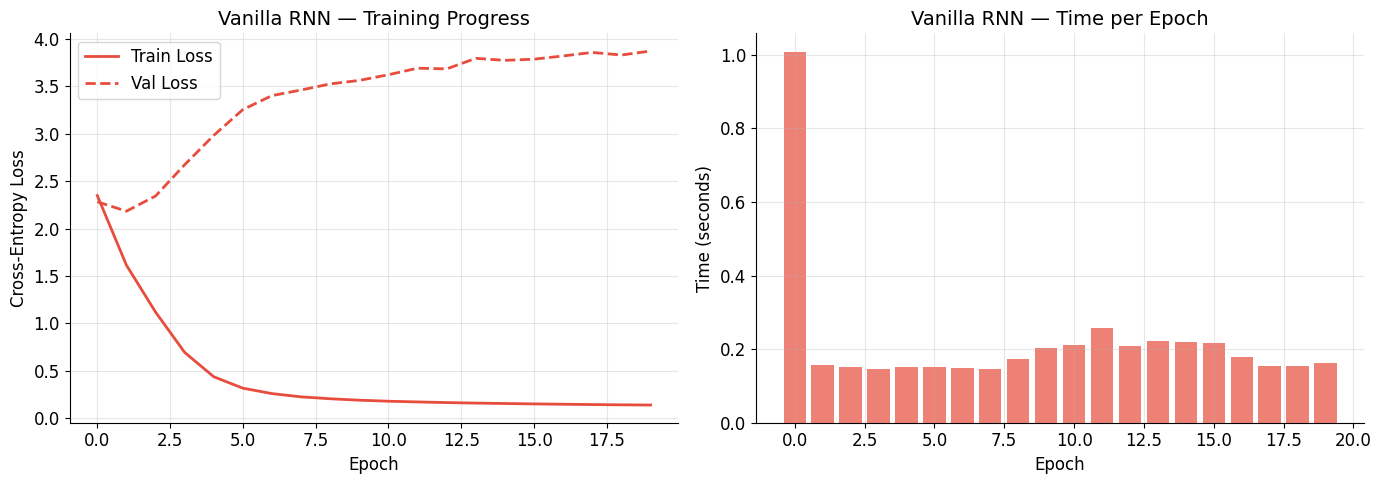


Final train loss: 0.1400
Final val loss  : 3.8717
Best val loss   : 2.1834


In [ ]:
# ============================================================================
# PLOT TRAINING CURVES — Visualize how the RNN learned
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(rnn_history['train_losses'], color=COLORS['rnn'], label='Train Loss', linewidth=2)
axes[0].plot(rnn_history['val_losses'], color=COLORS['rnn'], label='Val Loss', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Vanilla RNN — Training Progress')
axes[0].legend()

# Per-epoch training time
axes[1].bar(range(len(rnn_history['epoch_times'])), rnn_history['epoch_times'],
            color=COLORS['rnn'], alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Vanilla RNN — Time per Epoch')

plt.tight_layout()
plt.show()

print(f"\nFinal train loss: {rnn_history['train_losses'][-1]:.4f}")
print(f"Final val loss  : {rnn_history['val_losses'][-1]:.4f}")
print(f"Best val loss   : {min(rnn_history['val_losses']):.4f}")

<div style="background: #d4edda; border: 1px solid #28a745; padding: 15px 20px; border-radius: 10px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>✅ Part 2 Complete!</strong> We've built and trained a vanilla RNN. You should notice:
  <ul style="margin: 10px 0 0 0;">
    <li>The model learns basic character patterns (common letters, spaces, punctuation)</li>
    <li>Short-range structure is decent (real-looking word fragments)</li>
    <li>Long-range structure is poor (sentences don't make much sense)</li>
    <li>This is the <strong>vanishing gradient problem</strong> in action — the RNN can't remember far back</li>
  </ul>
  <p style="margin: 10px 0 0 0;">Next: <strong>LSTM</strong> — an architecture specifically designed to fix this problem.</p>
</div>

<a id="part3"></a>
<div style="background: linear-gradient(135deg, #3498db, #2980b9); padding: 25px 30px; border-radius: 14px; margin: 40px 0 20px 0; color: white; font-family: 'Segoe UI', Arial, sans-serif;">
  <h1 style="margin: 0; font-size: 2em;">Part 3: LSTM — Long Short-Term Memory</h1>
  <p style="margin: 10px 0 0 0; font-size: 1.1em; opacity: 0.9;">The gated architecture that solved the vanishing gradient problem</p>
</div>

<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #3498db; padding-bottom: 8px;">🧬 The LSTM Revolution (Hochreiter & Schmidhuber, 1997)</h2>

<p>The vanilla RNN has one fatal flaw: its hidden state is <strong>completely overwritten</strong> at every time step through a tanh activation. Information from 50 steps ago is practically gone. Sepp Hochreiter and Jürgen Schmidhuber proposed a radical solution:</p>

<div style="background: #ebf5fb; padding: 20px; border-radius: 10px; margin: 15px 0; text-align: center; font-size: 1.15em; border-left: 5px solid #3498db;">
  <strong>Instead of replacing the memory, let the network <em>learn</em> what to remember, what to forget, and what to output.</strong>
</div>

<p>The LSTM introduces two key innovations:</p>
<ol>
  <li><strong>Cell state (c<sub>t</sub>)</strong> — a separate "memory highway" that runs through time with minimal modification. Think of it as a conveyor belt: information can ride along it for many time steps without being corrupted.</li>
  <li><strong>Gates</strong> — learned sigmoid functions that control what information flows in and out of the cell state. Since sigmoid outputs values in [0, 1], gates act like soft switches.</li>
</ol>

<h3 style="color: #2d3436; margin-top: 25px;">🚪 The Three Gates</h3>

<table style="width:100%; border-collapse: collapse; margin: 15px 0;">
  <tr style="background: #ebf5fb;">
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #3498db; width: 20%;">Gate</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #3498db; width: 35%;">What It Does</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #3498db; width: 45%;">Analogy</th>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;"><strong>Forget Gate (f<sub>t</sub>)</strong></td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Decides what to <em>erase</em> from the cell state</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">"I finished reading this paragraph, I can forget the details and just keep the gist"</td>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;"><strong>Input Gate (i<sub>t</sub>)</strong></td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Decides what <em>new information</em> to store in the cell state</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">"This new character introduces the villain — that's important, store it!"</td>
  </tr>
  <tr>
    <td style="padding: 12px;"><strong>Output Gate (o<sub>t</sub>)</strong></td>
    <td style="padding: 12px;">Decides what to <em>output</em> from the cell state</td>
    <td style="padding: 12px;">"I know a lot of context, but right now I only need to output the next word"</td>
  </tr>
</table>

<h3 style="color: #2d3436; margin-top: 25px;">📐 The LSTM Equations</h3>

<div style="background: #2d3436; color: #dfe6e9; padding: 20px; border-radius: 8px; margin: 15px 0; font-size: 1.05em;">
<pre style="margin: 0; font-family: 'Courier New', monospace;">
Step 1 — Forget gate:     f_t = σ(W_f · [h_{t-1}, x_t] + b_f)
Step 2 — Input gate:      i_t = σ(W_i · [h_{t-1}, x_t] + b_i)
Step 3 — Candidate:       c̃_t = tanh(W_c · [h_{t-1}, x_t] + b_c)
Step 4 — Update cell:     c_t = f_t ⊙ c_{t-1}  +  i_t ⊙ c̃_t
Step 5 — Output gate:     o_t = σ(W_o · [h_{t-1}, x_t] + b_o)
Step 6 — Hidden state:    h_t = o_t ⊙ tanh(c_t)
</pre>
</div>

<p>Where <strong>⊙</strong> means element-wise multiplication and <strong>σ</strong> is the sigmoid function.</p>

<h3 style="color: #2d3436; margin-top: 25px;">🔑 Why This Solves Vanishing Gradients</h3>

<p>Look at <strong>Step 4</strong> — the cell state update. The key insight is that the cell state is updated <em>additively</em>:</p>

<div style="background: #eaf7ea; padding: 15px 20px; border-radius: 8px; margin: 10px 0; text-align: center; font-size: 1.1em;">
  c<sub>t</sub> = f<sub>t</sub> ⊙ c<sub>t-1</sub> + i<sub>t</sub> ⊙ c̃<sub>t</sub>
</div>

<p>When the forget gate f<sub>t</sub> is close to 1 ("remember everything") and the input gate i<sub>t</sub> is close to 0 ("nothing new"), the cell state is approximately <strong>c<sub>t</sub> ≈ c<sub>t-1</sub></strong>. This means gradients can flow backward through time <em>unchanged</em>, solving the vanishing gradient problem!</p>

<p>Compare this to the vanilla RNN where h<sub>t</sub> = tanh(W·[h<sub>t-1</sub>, x<sub>t</sub>]) — the tanh <em>always</em> squashes the gradient, regardless of the input.</p>

</div>

<div style="background: #e8f8f5; border-left: 5px solid #1abc9c; padding: 15px 20px; border-radius: 0 10px 10px 0; margin: 15px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>🔧 Step 3:</strong> Let's build the LSTM model using <code>nn.LSTM</code> and compare it to the vanilla RNN.
</div>

In [ ]:
# ============================================================================
# LSTM MODEL — Using PyTorch's nn.LSTM
# ============================================================================
# The architecture is almost identical to our CharRNN — we just swap
# nn.RNN for nn.LSTM. That's the beauty of PyTorch's modular design!
#
# Key difference from vanilla RNN:
#   - nn.LSTM maintains TWO internal states: (h_n, c_n)
#     h_n = hidden state (same as vanilla RNN)
#     c_n = cell state (the "memory highway" — LSTM's secret weapon)
#   - The output is still just the hidden states at each time step
#
# Note: nn.LSTM has ~4x more parameters than nn.RNN for the same
# hidden_dim, because it has 4 sets of weights (one per gate + candidate).
# ============================================================================

class CharLSTM(nn.Module):
    """Character-level language model using LSTM.

    The LSTM adds a cell state (memory highway) and three gates (forget,
    input, output) that learn to control information flow. This allows it
    to capture long-range dependencies that vanilla RNNs cannot.

    Args:
        vocab_size: Number of unique characters in the vocabulary
        embed_dim: Dimensionality of character embeddings
        hidden_dim: Size of the LSTM hidden state (and cell state)
        num_layers: Number of stacked LSTM layers (default: 1)
    """
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int = 1,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Same structure as CharRNN, just with LSTM instead of RNN
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # nn.LSTM internally implements all 4 gate computations
        # It manages both hidden state (h) and cell state (c)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Character indices, shape (batch, seq_length)

        Returns:
            Logits, shape (batch, seq_length, vocab_size)
        """
        # Step 1: Character indices → dense embeddings
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)

        # Step 2: Process through LSTM
        # lstm_out: hidden states at all time steps (batch, seq_len, hidden_dim)
        # (h_n, c_n): final hidden and cell states — we don't need them here
        lstm_out, (h_n, c_n) = self.lstm(embedded)

        # Step 3: Project to vocabulary logits
        logits = self.fc(lstm_out)  # (batch, seq_len, vocab_size)

        return logits


# Instantiate the model
lstm_model = CharLSTM(vocab_size, EMBED_DIM, HIDDEN_DIM)
print(lstm_model)

# Compare parameter counts
rnn_params  = sum(p.numel() for p in rnn_model.parameters())
lstm_params = sum(p.numel() for p in lstm_model.parameters())
print(f"\nVanilla RNN parameters : {rnn_params:,}")
print(f"LSTM parameters        : {lstm_params:,}")
print(f"LSTM / RNN ratio       : {lstm_params / rnn_params:.2f}x")
print(f"\n(LSTM has ~4x more parameters due to the 4 gate weight matrices)")

CharLSTM(
  (embedding): Embedding(42, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=42, bias=True)
)

Vanilla RNN parameters : 32,938
LSTM parameters        : 107,434
LSTM / RNN ratio       : 3.26x

(LSTM has ~4x more parameters due to the 4 gate weight matrices)


In [ ]:
# ============================================================================
# TRAIN THE LSTM
# ============================================================================
# Despite having more parameters, the LSTM should train smoothly and
# achieve a lower loss than the vanilla RNN. The gates help gradients
# flow, making optimization easier.
# ============================================================================

lstm_history = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name="LSTM",
)

all_results['LSTM'] = {
    'history': lstm_history,
    'model': lstm_model,
    'color': COLORS['lstm'],
}


Training LSTM
Total parameters     : 107,434
Trainable parameters : 107,434
  Epoch   1/20 │ Train Loss: 2.5614 │ Val Loss: 2.3160 │ Time: 0.2s
  Epoch   6/20 │ Train Loss: 0.3338 │ Val Loss: 3.0047 │ Time: 0.2s
  Epoch  11/20 │ Train Loss: 0.1539 │ Val Loss: 3.3858 │ Time: 0.2s
  Epoch  16/20 │ Train Loss: 0.1238 │ Val Loss: 3.7270 │ Time: 0.2s
  Epoch  20/20 │ Train Loss: 0.1132 │ Val Loss: 3.8685 │ Time: 0.2s
────────────────────────────────────────────────────────────
  Total training time: 3.7s


In [ ]:
# ============================================================================
# GENERATE TEXT — LSTM edition
# ============================================================================

lstm_generated = generate_text(lstm_model, SEED_TEXT, length=300, temperature=0.8)

print("Generated text (LSTM):")
print("=" * 60)
print(lstm_generated)
print("=" * 60)

all_results['LSTM']['generated'] = lstm_generated

Generated text (LSTM):
The village came fully alive. Dogs barked, horses
neighed, and the sound of conversation filled every corner. The mayor stood
at the center of the square, discussing plans for the upcoming harvest festival
with a group of eager villagers.

The harvest festival was the highlight of the year. Everyone contributed


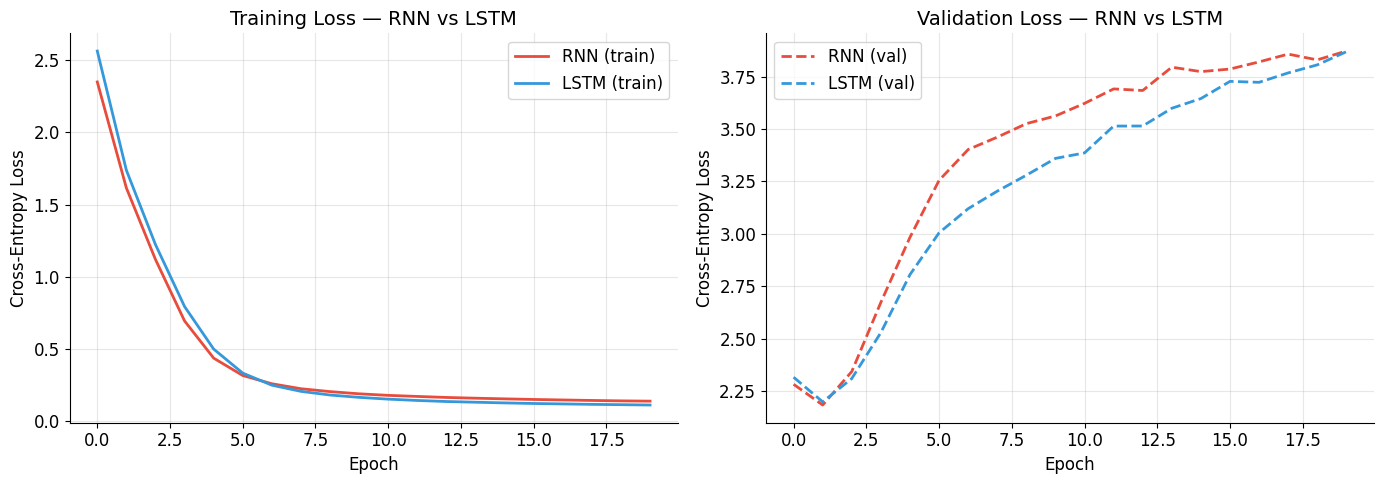


Best validation loss:
  RNN  : 2.1834
  LSTM : 2.1986


In [ ]:
# ============================================================================
# COMPARE RNN vs LSTM — Side-by-side training curves
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss comparison
axes[0].plot(rnn_history['train_losses'],  color=COLORS['rnn'],  label='RNN (train)',  linewidth=2)
axes[0].plot(lstm_history['train_losses'], color=COLORS['lstm'], label='LSTM (train)', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss — RNN vs LSTM')
axes[0].legend()

# Validation loss comparison
axes[1].plot(rnn_history['val_losses'],  color=COLORS['rnn'],  label='RNN (val)',  linewidth=2, linestyle='--')
axes[1].plot(lstm_history['val_losses'], color=COLORS['lstm'], label='LSTM (val)', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].set_title('Validation Loss — RNN vs LSTM')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nBest validation loss:")
print(f"  RNN  : {min(rnn_history['val_losses']):.4f}")
print(f"  LSTM : {min(lstm_history['val_losses']):.4f}")

<div style="background: #d4edda; border: 1px solid #28a745; padding: 15px 20px; border-radius: 10px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>✅ Part 3 Complete!</strong> The LSTM should outperform the vanilla RNN:
  <ul style="margin: 10px 0 0 0;">
    <li><strong>Lower loss</strong> — the gates allow more effective learning</li>
    <li><strong>Better text</strong> — more coherent words and phrases</li>
    <li><strong>More parameters</strong> — 4x more weights, but worth the cost</li>
    <li><strong>Smoother training</strong> — gradients flow more easily through the cell state highway</li>
  </ul>
  <p style="margin: 10px 0 0 0;">But can we get similar performance with <em>fewer</em> parameters? Enter the <strong>GRU</strong>.</p>
</div>

<a id="part4"></a>
<div style="background: linear-gradient(135deg, #2ecc71, #27ae60); padding: 25px 30px; border-radius: 14px; margin: 40px 0 20px 0; color: white; font-family: 'Segoe UI', Arial, sans-serif;">
  <h1 style="margin: 0; font-size: 2em;">Part 4: GRU — Gated Recurrent Unit</h1>
  <p style="margin: 10px 0 0 0; font-size: 1.1em; opacity: 0.9;">The elegant alternative — almost as powerful as LSTM, with fewer parameters</p>
</div>

<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #2ecc71; padding-bottom: 8px;">🎯 GRU: Simplicity Meets Power (Cho et al., 2014)</h2>

<p>The GRU (Gated Recurrent Unit) was proposed by Kyunghyun Cho and colleagues in 2014, about 17 years after the LSTM. The key insight: <em>do we really need all three gates AND a separate cell state?</em></p>

<p>The GRU simplifies the LSTM in two ways:</p>
<ol>
  <li><strong>Merges the cell state and hidden state</strong> into a single state vector</li>
  <li><strong>Combines the forget and input gates</strong> into a single "update gate"</li>
</ol>

<p>The result: <strong>2 gates instead of 3</strong>, <strong>no separate cell state</strong>, and <strong>~25% fewer parameters</strong> than LSTM — while often achieving comparable performance.</p>

<h3 style="color: #2d3436; margin-top: 25px;">🚪 The Two GRU Gates</h3>

<table style="width:100%; border-collapse: collapse; margin: 15px 0;">
  <tr style="background: #eafaf1;">
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #2ecc71; width: 25%;">Gate</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #2ecc71; width: 35%;">What It Does</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #2ecc71; width: 40%;">LSTM Equivalent</th>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;"><strong>Update Gate (z<sub>t</sub>)</strong></td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">How much of the old state to keep vs. replace with new info</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Combines LSTM's forget gate + input gate into one: <code>z = keep old</code>, <code>1-z = take new</code></td>
  </tr>
  <tr>
    <td style="padding: 12px;"><strong>Reset Gate (r<sub>t</sub>)</strong></td>
    <td style="padding: 12px;">How much of the old state to expose when computing the candidate</td>
    <td style="padding: 12px;">Roughly analogous to LSTM's output gate — controls what past info influences the candidate</td>
  </tr>
</table>

<h3 style="color: #2d3436; margin-top: 25px;">📐 The GRU Equations</h3>

<div style="background: #2d3436; color: #dfe6e9; padding: 20px; border-radius: 8px; margin: 15px 0; font-size: 1.05em;">
<pre style="margin: 0; font-family: 'Courier New', monospace;">
Step 1 — Update gate:    z_t = σ(W_z · [h_{t-1}, x_t] + b_z)
Step 2 — Reset gate:     r_t = σ(W_r · [h_{t-1}, x_t] + b_r)
Step 3 — Candidate:      h̃_t = tanh(W_h · [r_t ⊙ h_{t-1}, x_t] + b_h)
Step 4 — Final state:    h_t = z_t ⊙ h_{t-1}  +  (1 - z_t) ⊙ h̃_t
</pre>
</div>

<h3 style="color: #2d3436; margin-top: 25px;">🔄 The Elegant Update (Step 4)</h3>

<p>Look at the final equation: <code>h_t = z_t ⊙ h_{t-1} + (1 - z_t) ⊙ h̃_t</code></p>

<p>This is a <strong>linear interpolation</strong> between the old state and the candidate new state:</p>
<ul>
  <li>When <strong>z<sub>t</sub> ≈ 1</strong>: keep the old state ("nothing new worth remembering")</li>
  <li>When <strong>z<sub>t</sub> ≈ 0</strong>: use the new candidate ("completely overwrite the memory")</li>
  <li>Values in between: smoothly blend old and new</li>
</ul>

<p>Notice that <strong>(1 - z<sub>t</sub>)</strong> plays the role of LSTM's input gate. This coupling constraint (forget + input must sum to 1) is the key simplification. In LSTM, the forget and input gates are independent — they can both be high or both be low. The GRU enforces that forgetting and remembering are a <em>tradeoff</em>.</p>

<h3 style="color: #2d3436; margin-top: 25px;">⚖️ LSTM vs GRU: When to Use Which?</h3>

<table style="width:100%; border-collapse: collapse; margin: 15px 0;">
  <tr style="background: #f1f2f6;">
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">Factor</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">LSTM</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">GRU</th>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Parameters</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">More (4 gate matrices)</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Fewer (3 gate matrices)</td>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Training speed</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Slower per step</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Faster per step</td>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Long sequences</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Slight edge (separate cell state)</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Very competitive</td>
  </tr>
  <tr>
    <td style="padding: 12px;">Small datasets</td>
    <td style="padding: 12px;">May overfit more</td>
    <td style="padding: 12px;">Fewer params → better generalization</td>
  </tr>
</table>

<p><strong>Rule of thumb (from Géron):</strong> Start with GRU. Switch to LSTM if GRU doesn't perform well enough or if your sequences are very long and you have enough data to train the extra parameters.</p>

</div>

<div style="background: #e8f8f5; border-left: 5px solid #1abc9c; padding: 15px 20px; border-radius: 0 10px 10px 0; margin: 15px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>🔧 Step 4:</strong> Let's build the GRU model and see how it compares.
</div>

In [ ]:
# ============================================================================
# GRU MODEL — Using PyTorch's nn.GRU
# ============================================================================
# The GRU interface in PyTorch is nearly identical to nn.RNN and nn.LSTM.
# The only difference vs LSTM: the forward pass returns (output, h_n)
# instead of (output, (h_n, c_n)) — because there's no separate cell state.
#
# Internally, nn.GRU has 3 weight matrices per layer (vs 4 for LSTM):
#   - W_ir, W_hr: weights for the reset gate
#   - W_iz, W_hz: weights for the update gate
#   - W_in, W_hn: weights for the new gate (candidate)
# ============================================================================

class CharGRU(nn.Module):
    """Character-level language model using GRU.

    The GRU uses two gates (update and reset) to control information flow,
    offering comparable performance to LSTM with fewer parameters. It merges
    the cell state and hidden state into a single vector.

    Args:
        vocab_size: Number of unique characters in the vocabulary
        embed_dim: Dimensionality of character embeddings
        hidden_dim: Size of the GRU hidden state
        num_layers: Number of stacked GRU layers (default: 1)
    """
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int = 1,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # nn.GRU: just 2 gates (update, reset) instead of LSTM's 3
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Character indices, shape (batch, seq_length)

        Returns:
            Logits, shape (batch, seq_length, vocab_size)
        """
        embedded = self.embedding(x)       # (batch, seq_len, embed_dim)
        gru_out, h_n = self.gru(embedded)  # (batch, seq_len, hidden_dim)
        logits = self.fc(gru_out)          # (batch, seq_len, vocab_size)
        return logits


# Instantiate the model
gru_model = CharGRU(vocab_size, EMBED_DIM, HIDDEN_DIM)
print(gru_model)

# Compare parameter counts across all three models
gru_params = sum(p.numel() for p in gru_model.parameters())
print(f"\n{'Model':<15} {'Parameters':>12}  {'Relative':>10}")
print(f"{'─'*40}")
print(f"{'Vanilla RNN':<15} {rnn_params:>12,}  {'1.00x':>10}")
print(f"{'LSTM':<15} {lstm_params:>12,}  {f'{lstm_params/rnn_params:.2f}x':>10}")
print(f"{'GRU':<15} {gru_params:>12,}  {f'{gru_params/rnn_params:.2f}x':>10}")

CharGRU(
  (embedding): Embedding(42, 64)
  (gru): GRU(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=42, bias=True)
)

Model             Parameters    Relative
────────────────────────────────────────
Vanilla RNN           32,938       1.00x
LSTM                 107,434       3.26x
GRU                   82,602       2.51x


In [ ]:
# ============================================================================
# TRAIN THE GRU
# ============================================================================

gru_history = train_model(
    model=gru_model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name="GRU",
)

all_results['GRU'] = {
    'history': gru_history,
    'model': gru_model,
    'color': COLORS['gru'],
}


Training GRU
Total parameters     : 82,602
Trainable parameters : 82,602
  Epoch   1/20 │ Train Loss: 2.4341 │ Val Loss: 2.2440 │ Time: 0.2s
  Epoch   6/20 │ Train Loss: 0.1891 │ Val Loss: 3.1017 │ Time: 0.2s
  Epoch  11/20 │ Train Loss: 0.1228 │ Val Loss: 3.4268 │ Time: 0.2s
  Epoch  16/20 │ Train Loss: 0.1090 │ Val Loss: 3.5638 │ Time: 0.2s
  Epoch  20/20 │ Train Loss: 0.1033 │ Val Loss: 3.6991 │ Time: 0.2s
────────────────────────────────────────────────────────────
  Total training time: 3.3s


In [ ]:
# ============================================================================
# GENERATE TEXT — GRU edition
# ============================================================================

gru_generated = generate_text(gru_model, SEED_TEXT, length=300, temperature=0.8)

print("Generated text (GRU):")
print("=" * 60)
print(gru_generated)
print("=" * 60)

all_results['GRU']['generated'] = gru_generated

Generated text (GRU):
The village came fully alive. Dogs barked, horses
neighed, and the sound of conversation filled every corner. The mayor stood
at the center of the square, discussing plans for the upcoming harvest festival
with a group of eager villagers.

The harvest festival was the highlight of the year. Everyone contributed


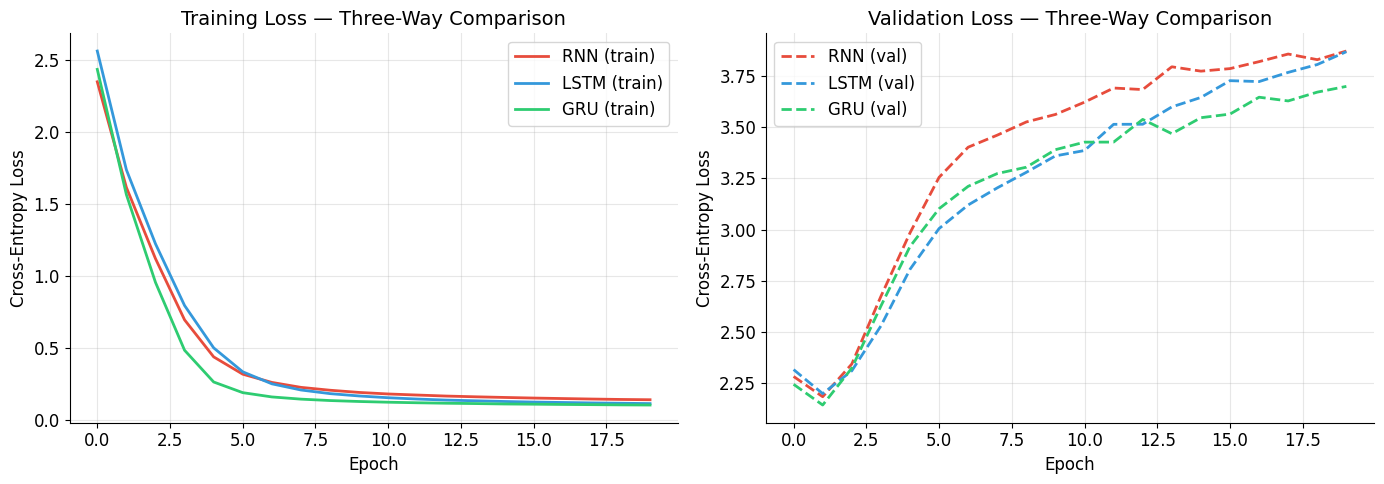

In [ ]:
# ============================================================================
# THREE-WAY COMPARISON — RNN vs LSTM vs GRU
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, result in all_results.items():
    if name == 'WaveNet':  # Haven't trained this yet
        continue
    axes[0].plot(result['history']['train_losses'], color=result['color'],
                 label=f'{name} (train)', linewidth=2)
    axes[1].plot(result['history']['val_losses'], color=result['color'],
                 label=f'{name} (val)', linewidth=2, linestyle='--')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss — Three-Way Comparison')
axes[0].legend()

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].set_title('Validation Loss — Three-Way Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background: #d4edda; border: 1px solid #28a745; padding: 15px 20px; border-radius: 10px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>✅ Part 4 Complete!</strong> We now have three recurrent models trained and compared:
  <ul style="margin: 10px 0 0 0;">
    <li><strong>GRU</strong> typically performs very close to LSTM with ~25% fewer parameters</li>
    <li>Both gated architectures (LSTM, GRU) significantly outperform vanilla RNN</li>
    <li>The parameter efficiency of GRU makes it a great default choice</li>
  </ul>
  <p style="margin: 10px 0 0 0;">Next: <strong>Deep RNNs & Practical Tricks</strong> — stacking layers, dropout, and more.</p>
</div>

<a id="part5"></a>
<div style="background: linear-gradient(135deg, #f39c12, #e67e22); padding: 25px 30px; border-radius: 14px; margin: 40px 0 20px 0; color: white; font-family: 'Segoe UI', Arial, sans-serif;">
  <h1 style="margin: 0; font-size: 2em;">Part 5: Deep RNNs & Practical Tricks</h1>
  <p style="margin: 10px 0 0 0; font-size: 1.1em; opacity: 0.9;">Stacking layers, dropout, bidirectional processing, and gradient clipping</p>
</div>

<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #f39c12; padding-bottom: 8px;">📚 Going Deeper: Stacked RNN Layers</h2>

<p>Just like we stack convolutional layers in CNNs to learn hierarchical features, we can <strong>stack RNN layers</strong> to learn more abstract representations of sequences.</p>

<pre style="background: #2d3436; color: #dfe6e9; padding: 20px; border-radius: 8px; font-size: 0.95em; overflow-x: auto;">
Input:    x₁     x₂     x₃     x₄
           │      │      │      │
           ▼      ▼      ▼      ▼
Layer 1: [RNN]──[RNN]──[RNN]──[RNN]  ← learns low-level patterns (letters, common pairs)
           │      │      │      │
           ▼      ▼      ▼      ▼
Layer 2: [RNN]──[RNN]──[RNN]──[RNN]  ← learns higher-level patterns (words, phrases)
           │      │      │      │
           ▼      ▼      ▼      ▼
Output:   y₁     y₂     y₃     y₄
</pre>

<p>Each layer processes the <em>output sequence</em> of the layer below it. In PyTorch, just set <code>num_layers=2</code> (or more) and it's handled automatically.</p>

<h3 style="color: #2d3436; margin-top: 25px;">🎭 Dropout in RNNs</h3>

<p>Dropout is the most popular regularization technique, but applying it to RNNs requires care:</p>

<ul>
  <li><strong>Between layers</strong> (PyTorch's built-in <code>dropout</code> parameter): Drops units in the output of each layer <em>except the last layer</em>. This is safe because it doesn't break the temporal continuity within a layer.</li>
  <li><strong>Within a layer</strong> (Gal & Ghahramani, 2016 — "variational dropout"): Use the <em>same</em> dropout mask at every time step. This is important! If you use a different mask at each step, you destroy the hidden state's memory. PyTorch doesn't do this automatically — you'd need a custom implementation.</li>
</ul>

<div style="background: #fff3cd; border-left: 5px solid #ffc107; padding: 15px 20px; border-radius: 0 8px 8px 0; margin: 15px 0;">
  <strong>⚠️ Important:</strong> PyTorch's <code>dropout</code> parameter in <code>nn.LSTM</code>/<code>nn.GRU</code> only applies dropout <strong>between layers</strong>, not within the recurrent connections. This means it has <strong>no effect when num_layers=1</strong>.
</div>

<h3 style="color: #2d3436; margin-top: 25px;">🔄 Bidirectional RNNs</h3>

<p>So far, our RNNs only process sequences left-to-right. But sometimes the <em>future</em> context is just as important as the past. A <strong>bidirectional RNN</strong> runs two independent RNNs:</p>
<ul>
  <li><strong>Forward RNN:</strong> processes x₁ → x₂ → ... → x_T (left to right)</li>
  <li><strong>Backward RNN:</strong> processes x_T → x_{T-1} → ... → x₁ (right to left)</li>
</ul>
<p>The outputs are concatenated at each time step, giving a hidden size of <code>2 × hidden_dim</code>.</p>

<div style="background: #fff0f0; border-left: 5px solid #e74c3c; padding: 15px 20px; border-radius: 0 8px 8px 0; margin: 15px 0;">
  <strong>⚠️ Caution:</strong> Bidirectional RNNs <strong>cannot be used for autoregressive generation</strong> (our task!). During generation, we predict the next character — we can't look into the future because it doesn't exist yet. Bidirectional RNNs are great for classification, tagging, and encoding — but not for generation.
</div>

<h3 style="color: #2d3436; margin-top: 25px;">✂️ Gradient Clipping</h3>

<p>We've been using gradient clipping throughout — let's understand why. During backpropagation through time, gradients can grow exponentially (the "exploding gradient" problem). Gradient clipping caps the total gradient norm:</p>

<div style="background: #f1f2f6; padding: 15px 20px; border-radius: 8px; margin: 10px 0; text-align: center; font-size: 1.05em;">
  <code>if ||g|| > threshold: g = g × (threshold / ||g||)</code><br>
  <small>This scales down the gradient vector while preserving its direction.</small>
</div>

<p>In our <code>train_model()</code> function, we use <code>clip_grad=1.0</code>, which is a common default. Without clipping, RNN training often diverges (loss goes to infinity).</p>

</div>

<div style="background: #e8f8f5; border-left: 5px solid #1abc9c; padding: 15px 20px; border-radius: 0 10px 10px 0; margin: 15px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>🔧 Step 5:</strong> Let's build a <strong>deep LSTM</strong> (2 layers + dropout) and see if depth helps.
</div>

In [ ]:
# ============================================================================
# DEEP LSTM — 2-layer LSTM with inter-layer dropout
# ============================================================================
# By stacking 2 LSTM layers:
#   - Layer 1 learns low-level patterns (common letter combinations)
#   - Layer 2 learns higher-level patterns (word structure, grammar)
#   - Dropout between layers prevents co-adaptation
#
# We set dropout=0.2, meaning 20% of the connections between Layer 1 and
# Layer 2 are randomly zeroed during training. This forces each layer to
# learn robust features that don't depend on specific neurons in the other layer.
# ============================================================================

class DeepCharLSTM(nn.Module):
    """Deep character-level language model with stacked LSTM layers and dropout.

    This model demonstrates the practical tricks that make RNNs work well:
    stacking multiple layers for hierarchical feature learning, and dropout
    for regularization.

    Args:
        vocab_size: Number of unique characters
        embed_dim: Embedding dimensionality
        hidden_dim: LSTM hidden state size
        num_layers: Number of stacked LSTM layers
        dropout: Dropout probability between LSTM layers
    """
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int = 2,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Multi-layer LSTM with dropout between layers
        # Note: dropout only applies between layers, not within them
        # So dropout has no effect when num_layers=1
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Additional dropout before the output layer
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(x)                 # (batch, seq, embed)
        lstm_out, (h_n, c_n) = self.lstm(embedded)   # (batch, seq, hidden)
        lstm_out = self.dropout(lstm_out)             # Apply dropout
        logits = self.fc(lstm_out)                    # (batch, seq, vocab)
        return logits


# Instantiate the deep model
deep_lstm_model = DeepCharLSTM(vocab_size, EMBED_DIM, HIDDEN_DIM, num_layers=2, dropout=0.2)
print(deep_lstm_model)

deep_params = sum(p.numel() for p in deep_lstm_model.parameters())
print(f"\nDeep LSTM parameters: {deep_params:,}")
print(f"vs single-layer LSTM: {lstm_params:,} ({deep_params/lstm_params:.2f}x)")

DeepCharLSTM(
  (embedding): Embedding(42, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=42, bias=True)
)

Deep LSTM parameters: 239,530
vs single-layer LSTM: 107,434 (2.23x)


In [ ]:
# ============================================================================
# TRAIN THE DEEP LSTM
# ============================================================================

deep_lstm_history = train_model(
    model=deep_lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name="Deep LSTM (2 layers)",
)

all_results['Deep LSTM'] = {
    'history': deep_lstm_history,
    'model': deep_lstm_model,
    'color': '#1a5276',  # Dark blue
}


Training Deep LSTM (2 layers)
Total parameters     : 239,530
Trainable parameters : 239,530
  Epoch   1/20 │ Train Loss: 2.7843 │ Val Loss: 2.4287 │ Time: 0.3s
  Epoch   6/20 │ Train Loss: 0.5904 │ Val Loss: 2.8944 │ Time: 0.2s
  Epoch  11/20 │ Train Loss: 0.2141 │ Val Loss: 3.6786 │ Time: 0.2s
  Epoch  16/20 │ Train Loss: 0.1601 │ Val Loss: 3.9432 │ Time: 0.3s
  Epoch  20/20 │ Train Loss: 0.1446 │ Val Loss: 4.3353 │ Time: 0.3s
────────────────────────────────────────────────────────────
  Total training time: 4.8s


In [ ]:
# ============================================================================
# GENERATE TEXT — Deep LSTM
# ============================================================================

deep_generated = generate_text(deep_lstm_model, SEED_TEXT, length=300, temperature=0.8)
print("Generated text (Deep LSTM, 2 layers):")
print("=" * 60)
print(deep_generated)
print("=" * 60)

all_results['Deep LSTM']['generated'] = deep_generated

Generated text (Deep LSTM, 2 layers):
The village came fully alive. Dogs barked, horses
neighed, and the sound of conversation filled every corner. The mayor stood
at the center of the square, discussing plans for the upcoming harvest festival
with a group of eager villagers.

The harvest festival was the highlight of the year. Everyone contributed


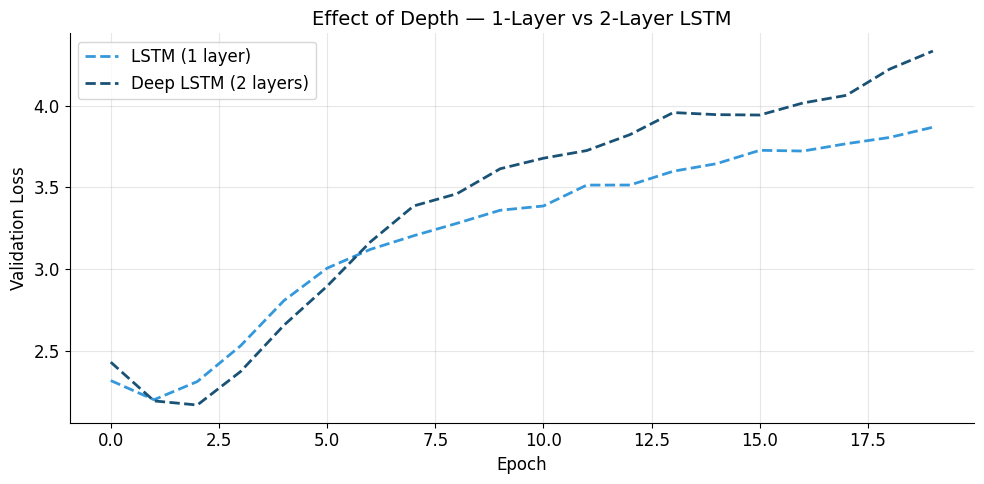


Best val loss (1-layer LSTM) : 2.1986
Best val loss (2-layer LSTM): 2.1661


In [ ]:
# ============================================================================
# VISUALIZE: Effect of depth — 1-layer vs 2-layer LSTM
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(lstm_history['val_losses'], color=COLORS['lstm'],
        label='LSTM (1 layer)', linewidth=2, linestyle='--')
ax.plot(deep_lstm_history['val_losses'], color='#1a5276',
        label='Deep LSTM (2 layers)', linewidth=2, linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Effect of Depth — 1-Layer vs 2-Layer LSTM')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nBest val loss (1-layer LSTM) : {min(lstm_history['val_losses']):.4f}")
print(f"Best val loss (2-layer LSTM): {min(deep_lstm_history['val_losses']):.4f}")

<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #f39c12; padding-bottom: 8px;">🧪 Temperature Experiment — How Randomness Affects Generation</h2>

<p>The <code>temperature</code> parameter is a simple but powerful knob that controls the randomness of generated text. Let's see it in action with our best model so far:</p>

<table style="width:100%; border-collapse: collapse; margin: 15px 0;">
  <tr style="background: #f1f2f6;">
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">Temperature</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">Effect</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">Analogy</th>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;"><strong>0.2</strong> (low)</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Very deterministic — always picks the most likely character</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">A careful, boring writer who repeats safe phrases</td>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;"><strong>0.8</strong> (medium)</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Balanced — likely characters preferred but with variety</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">A natural, fluent writer</td>
  </tr>
  <tr>
    <td style="padding: 12px;"><strong>1.5</strong> (high)</td>
    <td style="padding: 12px;">Very random — unlikely characters get a fair shot</td>
    <td style="padding: 12px;">A creative but sometimes nonsensical writer</td>
  </tr>
</table>

</div>

In [ ]:
# ============================================================================
# TEMPERATURE COMPARISON — Same model, different temperatures
# ============================================================================
# Using our best model (Deep LSTM or GRU), generate text at 3 temperatures
# to show how this single parameter dramatically changes output character.
# ============================================================================

# Pick whichever model had the best validation loss
best_name = min(
    {k: v for k, v in all_results.items() if k != 'WaveNet'},
    key=lambda k: min(all_results[k]['history']['val_losses'])
)
best_model = all_results[best_name]['model']
print(f"Using best model so far: {best_name}\n")

for temp in [0.2, 0.8, 1.5]:
    text = generate_text(best_model, "The morning ", length=150, temperature=temp)
    print(f"--- Temperature = {temp} ---")
    print(text)
    print()

Using best model so far: GRU

--- Temperature = 0.2 ---
The morning wore on, the village came fully alive. Dogs barked, horses
neighed, and the sound of conversation filled every corner. The mayor stood
at the center o

--- Temperature = 0.8 ---
The morning songs, filling the air with melodies that
echoed through the trees. The river wound its way through the landscape,
sparkling in the golden light of da

--- Temperature = 1.5 ---
The morning still felt
like a gift. The mountains never chage, Deager villagers.

The harvest festival
watching the worce and purped newed through the trees. The 



<div style="background: #d4edda; border: 1px solid #28a745; padding: 15px 20px; border-radius: 10px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>✅ Part 5 Complete!</strong> Key takeaways from practical tricks:
  <ul style="margin: 10px 0 0 0;">
    <li><strong>Stacking layers</strong> can help, but more layers need more data to justify the extra parameters</li>
    <li><strong>Dropout</strong> between RNN layers prevents overfitting — critical for larger models</li>
    <li><strong>Gradient clipping</strong> is essential for stable RNN training</li>
    <li><strong>Temperature</strong> controls the creativity vs. coherence tradeoff during generation</li>
    <li><strong>Bidirectional</strong> RNNs are powerful for encoding but can't be used for autoregressive generation</li>
  </ul>
  <p style="margin: 10px 0 0 0;">Next: <strong>WaveNet</strong> — a completely different approach that uses convolutions instead of recurrence!</p>
</div>

<a id="part6"></a>
<div style="background: linear-gradient(135deg, #9b59b6, #8e44ad); padding: 25px 30px; border-radius: 14px; margin: 40px 0 20px 0; color: white; font-family: 'Segoe UI', Arial, sans-serif;">
  <h1 style="margin: 0; font-size: 2em;">Part 6: WaveNet — Convolutions for Sequences</h1>
  <p style="margin: 10px 0 0 0; font-size: 1.1em; opacity: 0.9;">A radically different approach — no recurrence at all!</p>
</div>

<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #9b59b6; padding-bottom: 8px;">🌊 WaveNet: From Audio to Text (van den Oord et al., 2016)</h2>

<p>WaveNet was originally developed by DeepMind for <strong>speech synthesis</strong> — generating human-sounding audio sample by sample. But its core ideas apply to <em>any</em> sequence modeling task, including our character-level language modeling.</p>

<p>The revolutionary insight: <strong>you don't need recurrence to model sequences</strong>. Instead, WaveNet uses <em>causal dilated convolutions</em> — a type of 1D convolution that:</p>
<ol>
  <li>Only looks at the <strong>past</strong> (causal — no peeking into the future)</li>
  <li>Has an <strong>exponentially growing receptive field</strong> (dilated — covers long-range context efficiently)</li>
</ol>

<h3 style="color: #2d3436; margin-top: 25px;">🔍 Problem with Regular Convolutions</h3>

<p>A regular 1D convolution with kernel size 3 looks at 3 consecutive positions. To cover a context of 512 time steps, you'd need ~170 layers! That's impractical.</p>

<h3 style="color: #2d3436; margin-top: 25px;">💡 The Dilation Trick</h3>

<p><strong>Dilated convolutions</strong> skip positions in the input with a fixed stride (the "dilation rate"). By <em>doubling</em> the dilation at each layer, the receptive field grows exponentially:</p>

<pre style="background: #2d3436; color: #dfe6e9; padding: 20px; border-radius: 8px; font-size: 0.9em; overflow-x: auto;">
Input:        ● ● ● ● ● ● ● ● ● ● ● ● ● ● ● ●

Dilation=1:   ├─┤                                    Looks at 2 neighbors
              ● ● ●     kernel_size=2

Dilation=2:   ├───┤                                  Skips 1, sees 4 apart
              ●   ●     kernel_size=2

Dilation=4:   ├───────┤                              Skips 3, sees 8 apart
              ●       ●  kernel_size=2

Dilation=8:   ├───────────────┤                      Skips 7, sees 16 apart
              ●               ●  kernel_size=2

Stack all 4 layers → receptive field = 2+2+4+8 = 16 positions!
With just 4 layers! (Without dilation, you'd need 16 layers)
</pre>

<p>In general, with <em>L</em> layers of dilation [1, 2, 4, ..., 2^(L-1)], the receptive field is <strong>2^L</strong>. So 10 layers covers 1,024 time steps — perfect for our SEQ_LENGTH=64.</p>

<h3 style="color: #2d3436; margin-top: 25px;">🚫 Causal Convolutions</h3>

<p>Regular convolutions look both forward and backward in time. For autoregressive generation (predicting the next character), we must ensure the model can only see <strong>past and present</strong>, never the future. This is achieved with <strong>causal padding</strong>:</p>

<div style="background: #f1f2f6; padding: 15px 20px; border-radius: 8px; margin: 10px 0; text-align: center; font-size: 1.05em;">
  <code>padding = (kernel_size - 1) × dilation</code><br>
  <small>Pad on the left side only, then trim the right side to maintain sequence length.</small>
</div>

<h3 style="color: #2d3436; margin-top: 25px;">🏗️ Residual Connections</h3>

<p>Like ResNet, WaveNet uses <strong>residual connections</strong> to allow deep stacking without degradation. Each block computes:</p>

<div style="background: #f1f2f6; padding: 15px 20px; border-radius: 8px; margin: 10px 0; text-align: center; font-size: 1.05em;">
  <code>output = input + CausalConv(activation(input))</code>
</div>

<h3 style="color: #2d3436; margin-top: 25px;">⚡ Advantages Over RNNs</h3>

<table style="width:100%; border-collapse: collapse; margin: 15px 0;">
  <tr style="background: #f5eef8;">
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #9b59b6;">Feature</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #9b59b6;">RNN/LSTM/GRU</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #9b59b6;">WaveNet (Dilated Conv)</th>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Processing</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Sequential (step by step)</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;"><strong>Parallel</strong> (all positions at once)</td>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Training speed</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Slow (can't parallelize across time)</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;"><strong>Fast</strong> (convolutions are highly parallel on GPU)</td>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Gradient flow</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Through time (vanishing gradients)</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;"><strong>Direct path</strong> via residual connections</td>
  </tr>
  <tr>
    <td style="padding: 12px;">Receptive field</td>
    <td style="padding: 12px;">Unlimited (in theory)</td>
    <td style="padding: 12px;">Fixed but exponentially large</td>
  </tr>
</table>

</div>

<div style="background: #e8f8f5; border-left: 5px solid #1abc9c; padding: 15px 20px; border-radius: 0 10px 10px 0; margin: 15px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>🔧 Step 6:</strong> Let's build a WaveNet-style model using <code>nn.Conv1d</code> with causal dilated convolutions.
</div>

In [ ]:
# ============================================================================
# CAUSAL CONV1D BLOCK — The building block of WaveNet
# ============================================================================
# A causal convolution ensures that the prediction at time t only depends
# on inputs at times ≤ t (no future leakage). We achieve this by:
#   1. Padding the left side of the input by (kernel_size - 1) * dilation
#   2. Applying a standard Conv1d (no built-in padding)
#   3. Trimming the right side to maintain the original sequence length
#
# The dilation parameter controls the spacing between kernel elements:
#   dilation=1: standard convolution [x₁, x₂, x₃]
#   dilation=2: skip every other:    [x₁, _, x₃, _, x₅]
#   dilation=4: skip every 3:        [x₁, _, _, _, x₅, _, _, _, x₉]
# ============================================================================

class CausalConv1dBlock(nn.Module):
    """Causal dilated convolution block with residual connection.

    This is the fundamental building block of WaveNet. It applies a causal
    (no future leakage) dilated (exponentially growing receptive field)
    1D convolution, followed by a GELU activation and a residual connection.

    Args:
        channels: Number of input and output channels (must be equal for residual)
        kernel_size: Size of the convolution kernel
        dilation: Dilation factor (spacing between kernel elements)
    """
    def __init__(self, channels: int, kernel_size: int = 2, dilation: int = 1):
        super().__init__()

        # Calculate the left-padding needed for causal convolution
        # This ensures output[t] depends only on input[≤t]
        self.causal_padding = (kernel_size - 1) * dilation

        # Standard Conv1d — we handle padding manually for causality
        self.conv = nn.Conv1d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=0,  # We pad manually for causal behavior
        )

        # Layer normalization for stable training
        # Applied per-channel across the sequence dimension
        self.norm = nn.LayerNorm(channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass with causal padding and residual connection.

        Args:
            x: Input tensor, shape (batch, channels, seq_length)

        Returns:
            Output tensor, same shape as input (residual connection preserves shape)
        """
        residual = x

        # Step 1: Pad the LEFT side only (causal = no future information)
        # F.pad format for 1D: (left_pad, right_pad)
        x_padded = F.pad(x, (self.causal_padding, 0))

        # Step 2: Apply convolution
        # Input:  (batch, channels, seq_length + padding)
        # Output: (batch, channels, seq_length)  — padding is consumed
        out = self.conv(x_padded)

        # Step 3: Layer norm (expects channels as last dim)
        out = out.transpose(1, 2)   # (batch, seq, channels)
        out = self.norm(out)
        out = out.transpose(1, 2)   # (batch, channels, seq)

        # Step 4: Activation
        out = F.gelu(out)

        # Step 5: Residual connection — add input back to output
        # This allows gradients to flow directly through the skip connection
        return out + residual


print("✓ CausalConv1dBlock defined")
print(f"  Example: dilation=4, kernel_size=2 → causal_padding = {(2-1)*4}")
print(f"  This block looks back {(2-1)*4 + 1} time steps")

✓ CausalConv1dBlock defined
  Example: dilation=4, kernel_size=2 → causal_padding = 4
  This block looks back 5 time steps


In [ ]:
# ============================================================================
# WAVENET MODEL — Stack of causal dilated convolution blocks
# ============================================================================
# Architecture:
#   1. Embedding layer: character indices → dense vectors
#   2. Input projection: embed_dim → hidden_dim (to match conv channels)
#   3. Stack of CausalConv1dBlocks with exponentially increasing dilation:
#      dilation = [1, 2, 4, 8, 16, 32, 64]  (7 layers)
#      receptive field = 1 + 1 + 2 + 4 + 8 + 16 + 32 + 64 = 128 positions!
#   4. Output projection: hidden_dim → vocab_size
#
# Key insight: Unlike RNNs, ALL positions are computed in parallel during
# training. The causal padding ensures no future leakage, so the loss at
# each position is a valid next-character prediction.
# ============================================================================

class CharWaveNet(nn.Module):
    """Character-level language model using WaveNet-style dilated causal convolutions.

    This model replaces recurrence with a stack of dilated causal convolutions.
    Each layer doubles the dilation, creating an exponentially growing receptive
    field. The entire sequence is processed in parallel (no sequential bottleneck).

    Args:
        vocab_size: Number of unique characters
        embed_dim: Embedding dimensionality
        hidden_dim: Number of channels in convolution layers
        num_layers: Number of dilated conv blocks (receptive field = 2^num_layers)
        kernel_size: Convolution kernel size (default: 2)
    """
    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int = 7,
        kernel_size: int = 2,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Project embedding dimension to conv channels
        self.input_proj = nn.Linear(embed_dim, hidden_dim)

        # Stack of causal dilated conv blocks
        # Dilation doubles at each layer: 1, 2, 4, 8, 16, 32, 64
        self.conv_blocks = nn.ModuleList([
            CausalConv1dBlock(
                channels=hidden_dim,
                kernel_size=kernel_size,
                dilation=2**i,  # Exponential dilation!
            )
            for i in range(num_layers)
        ])

        # Project back to vocabulary size
        self.output_proj = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Character indices, shape (batch, seq_length)

        Returns:
            Logits, shape (batch, seq_length, vocab_size)
        """
        # Step 1: Embed characters
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)

        # Step 2: Project to conv channels
        h = self.input_proj(embedded)  # (batch, seq_len, hidden_dim)

        # Step 3: Transpose for Conv1d: (batch, channels, seq_len)
        # Conv1d expects the channel dimension before the sequence dimension
        h = h.transpose(1, 2)  # (batch, hidden_dim, seq_len)

        # Step 4: Pass through all causal dilated conv blocks
        for block in self.conv_blocks:
            h = block(h)

        # Step 5: Transpose back and project to vocabulary
        h = h.transpose(1, 2)  # (batch, seq_len, hidden_dim)
        logits = self.output_proj(h)  # (batch, seq_len, vocab_size)

        return logits


# Instantiate the model
wavenet_model = CharWaveNet(vocab_size, EMBED_DIM, HIDDEN_DIM, num_layers=7)
print(wavenet_model)

wavenet_params = sum(p.numel() for p in wavenet_model.parameters())
receptive_field = 2**7  # 2^num_layers
print(f"\nWaveNet parameters  : {wavenet_params:,}")
print(f"Receptive field     : {receptive_field} characters")
print(f"Dilation pattern    : {[2**i for i in range(7)]}")

# Full comparison table
print(f"\n{'Model':<15} {'Parameters':>12}")
print(f"{'─'*30}")
print(f"{'Vanilla RNN':<15} {rnn_params:>12,}")
print(f"{'LSTM':<15} {lstm_params:>12,}")
print(f"{'GRU':<15} {gru_params:>12,}")
print(f"{'Deep LSTM':<15} {deep_params:>12,}")
print(f"{'WaveNet':<15} {wavenet_params:>12,}")

CharWaveNet(
  (embedding): Embedding(42, 64)
  (input_proj): Linear(in_features=64, out_features=128, bias=True)
  (conv_blocks): ModuleList(
    (0): CausalConv1dBlock(
      (conv): Conv1d(128, 128, kernel_size=(2,), stride=(1,))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (1): CausalConv1dBlock(
      (conv): Conv1d(128, 128, kernel_size=(2,), stride=(1,), dilation=(2,))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (2): CausalConv1dBlock(
      (conv): Conv1d(128, 128, kernel_size=(2,), stride=(1,), dilation=(4,))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (3): CausalConv1dBlock(
      (conv): Conv1d(128, 128, kernel_size=(2,), stride=(1,), dilation=(8,))
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (4): CausalConv1dBlock(
      (conv): Conv1d(128, 128, kernel_size=(2,), stride=(1,), dilation=(16,))
      (norm): LayerNorm((128,), eps=1e-05, element

In [ ]:
# ============================================================================
# TRAIN THE WAVENET
# ============================================================================
# WaveNet processes ALL positions in parallel during training, so each
# epoch should be noticeably faster than the RNN variants on a GPU.
# On CPU, the difference is smaller because Conv1d parallelism matters
# less without GPU-level parallelism.
# ============================================================================

wavenet_history = train_model(
    model=wavenet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_name="WaveNet",
)

all_results['WaveNet'] = {
    'history': wavenet_history,
    'model': wavenet_model,
    'color': COLORS['wavenet'],
}


Training WaveNet
Total parameters     : 248,490
Trainable parameters : 248,490
  Epoch   1/20 │ Train Loss: 1.5013 │ Val Loss: 3.0741 │ Time: 0.9s
  Epoch   6/20 │ Train Loss: 0.1169 │ Val Loss: 4.4533 │ Time: 0.4s
  Epoch  11/20 │ Train Loss: 0.1068 │ Val Loss: 4.7187 │ Time: 0.4s
  Epoch  16/20 │ Train Loss: 0.1021 │ Val Loss: 5.2371 │ Time: 0.4s
  Epoch  20/20 │ Train Loss: 0.1008 │ Val Loss: 5.1715 │ Time: 0.4s
────────────────────────────────────────────────────────────
  Total training time: 7.8s


In [ ]:
# ============================================================================
# GENERATE TEXT — WaveNet edition
# ============================================================================
# Note: During generation, WaveNet is actually SLOWER than RNNs because
# it must re-run the entire convolutional stack for each new character.
# RNNs only need a single step (using the cached hidden state).
# This is an important practical consideration!
# ============================================================================

wavenet_generated = generate_text(wavenet_model, SEED_TEXT, length=300, temperature=0.8)

print("Generated text (WaveNet):")
print("=" * 60)
print(wavenet_generated)
print("=" * 60)

all_results['WaveNet']['generated'] = wavenet_generated

Generated text (WaveNet):
The village came fully alive. Dogs barked, horses
neighed, and the sound of conversation filled every corner. The mayor stood
at the center of the square, discussing plans for the upcoming harvest festival
with a group of eager villagers.

The harvest festival was the highlight of the year. Everyone contributed


<div style="background: #d4edda; border: 1px solid #28a745; padding: 15px 20px; border-radius: 10px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif;">
  <strong>✅ Part 6 Complete!</strong> WaveNet demonstrates that:
  <ul style="margin: 10px 0 0 0;">
    <li><strong>Recurrence is not required</strong> for sequence modeling — convolutions work too</li>
    <li><strong>Dilated convolutions</strong> give exponential receptive field growth with linear parameter growth</li>
    <li><strong>Parallel training</strong> is much faster on GPUs than sequential RNN processing</li>
    <li><strong>Trade-off:</strong> fast training but slow autoregressive generation (no hidden state caching)</li>
    <li>This idea of non-recurrent sequence modeling paved the way for <strong>Transformers</strong>!</li>
  </ul>
  <p style="margin: 10px 0 0 0;">Next: <strong>Grand Comparison</strong> — putting all four architectures head to head.</p>
</div>

<a id="part7"></a>
<div style="background: linear-gradient(135deg, #2d3436, #636e72); padding: 25px 30px; border-radius: 14px; margin: 40px 0 20px 0; color: white; font-family: 'Segoe UI', Arial, sans-serif;">
  <h1 style="margin: 0; font-size: 2em;">Part 7: Grand Comparison & Takeaways</h1>
  <p style="margin: 10px 0 0 0; font-size: 1.1em; opacity: 0.9;">All four architectures, head to head — benchmarks, analysis, and practical guidance</p>
</div>

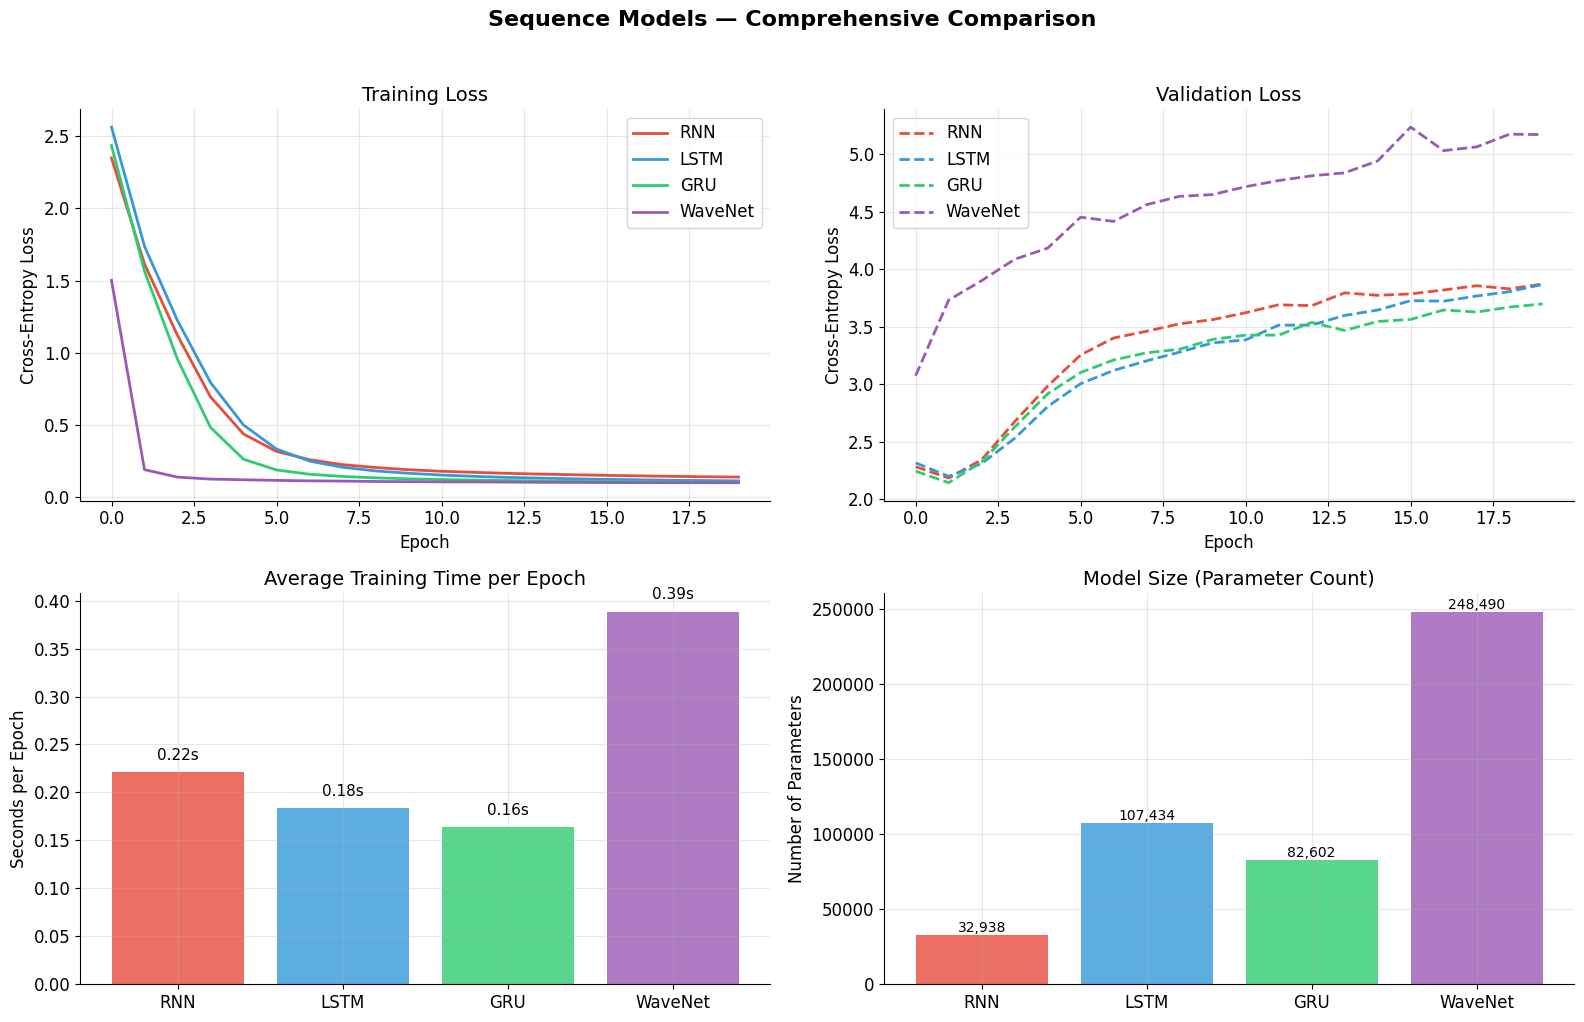

In [ ]:
# ============================================================================
# COMPREHENSIVE COMPARISON PLOT — All models side by side
# ============================================================================

# Filter to the 4 main models (exclude Deep LSTM to keep it clean)
main_models = ['RNN', 'LSTM', 'GRU', 'WaveNet']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Plot 1: Training Loss ---
ax = axes[0, 0]
for name in main_models:
    if name in all_results:
        ax.plot(all_results[name]['history']['train_losses'],
                color=all_results[name]['color'], label=name, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Training Loss')
ax.legend()

# --- Plot 2: Validation Loss ---
ax = axes[0, 1]
for name in main_models:
    if name in all_results:
        ax.plot(all_results[name]['history']['val_losses'],
                color=all_results[name]['color'], label=name, linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Validation Loss')
ax.legend()

# --- Plot 3: Training Time per Epoch ---
ax = axes[1, 0]
avg_times = []
colors_list = []
names_list = []
for name in main_models:
    if name in all_results:
        avg_time = np.mean(all_results[name]['history']['epoch_times'])
        avg_times.append(avg_time)
        colors_list.append(all_results[name]['color'])
        names_list.append(name)
bars = ax.bar(names_list, avg_times, color=colors_list, alpha=0.8)
ax.set_ylabel('Seconds per Epoch')
ax.set_title('Average Training Time per Epoch')
for bar, t in zip(bars, avg_times):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{t:.2f}s', ha='center', va='bottom', fontsize=11)

# --- Plot 4: Parameter Count ---
ax = axes[1, 1]
param_counts = []
for name in main_models:
    if name in all_results:
        params = sum(p.numel() for p in all_results[name]['model'].parameters())
        param_counts.append(params)
bars = ax.bar(names_list, param_counts, color=colors_list, alpha=0.8)
ax.set_ylabel('Number of Parameters')
ax.set_title('Model Size (Parameter Count)')
for bar, p in zip(bars, param_counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'{p:,}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Sequence Models — Comprehensive Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# SUMMARY TABLE — All metrics in one place
# ============================================================================

print("\n" + "=" * 85)
print(f"{'MODEL COMPARISON SUMMARY':^85}")
print("=" * 85)
print(f"{'Model':<15} {'Params':>10} {'Best Train':>12} {'Best Val':>10} {'Avg Time':>10} {'Total Time':>12}")
print("─" * 85)

for name in ['RNN', 'LSTM', 'GRU', 'Deep LSTM', 'WaveNet']:
    if name not in all_results:
        continue
    r = all_results[name]
    params = sum(p.numel() for p in r['model'].parameters())
    best_train = min(r['history']['train_losses'])
    best_val = min(r['history']['val_losses'])
    avg_time = np.mean(r['history']['epoch_times'])
    total_time = sum(r['history']['epoch_times'])
    print(f"{name:<15} {params:>10,} {best_train:>12.4f} {best_val:>10.4f} {avg_time:>9.2f}s {total_time:>11.1f}s")

print("=" * 85)


                              MODEL COMPARISON SUMMARY                               
Model               Params   Best Train   Best Val   Avg Time   Total Time
─────────────────────────────────────────────────────────────────────────────────────
RNN                 32,938       0.1400     2.1834      0.22s         4.4s
LSTM               107,434       0.1132     2.1986      0.18s         3.7s
GRU                 82,602       0.1033     2.1429      0.16s         3.3s
Deep LSTM          239,530       0.1446     2.1661      0.24s         4.8s
WaveNet            248,490       0.1008     3.0741      0.39s         7.8s


In [ ]:
# ============================================================================
# GENERATED TEXT COMPARISON — Same seed, all models
# ============================================================================

print("\n" + "=" * 70)
print(f"{'GENERATED TEXT COMPARISON':^70}")
print(f"Seed: {repr(SEED_TEXT)}")
print("=" * 70)

for name in ['RNN', 'LSTM', 'GRU', 'WaveNet']:
    if name in all_results and 'generated' in all_results[name]:
        print(f"\n--- {name} ---")
        # Show first 200 chars of generated text (after seed)
        text = all_results[name]['generated']
        print(text[:200])
        print()


                      GENERATED TEXT COMPARISON                       
Seed: 'The village '

--- RNN ---
The village came fully alive. Dogs barked, horses
neighed, and the sound of chill wer the filled with the noise and energy of her students. Teaching was her calling,
and she approached each day with r


--- LSTM ---
The village came fully alive. Dogs barked, horses
neighed, and the sound of conversation filled every corner. The mayor stood
at the center of the square, discussing plans for the upcoming harvest fes


--- GRU ---
The village came fully alive. Dogs barked, horses
neighed, and the sound of conversation filled every corner. The mayor stood
at the center of the square, discussing plans for the upcoming harvest fes


--- WaveNet ---
The village came fully alive. Dogs barked, horses
neighed, and the sound of conversation filled every corner. The mayor stood
at the center of the square, discussing plans for the upcoming harvest fes



<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #2d3436; padding-bottom: 8px;">📊 Analysis & Key Takeaways</h2>

<h3 style="color: #2d3436; margin-top: 20px;">1. Architecture Comparison Summary</h3>

<table style="width:100%; border-collapse: collapse; margin: 15px 0;">
  <tr style="background: #f1f2f6;">
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">Architecture</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">Year</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">Key Innovation</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">Strength</th>
    <th style="padding: 12px; text-align: left; border-bottom: 2px solid #ddd;">Weakness</th>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;"><strong style="color: #e74c3c;">Vanilla RNN</strong></td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">1986</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Recurrence (hidden state feedback)</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Simple, few parameters</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Vanishing gradients, short memory</td>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;"><strong style="color: #3498db;">LSTM</strong></td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">1997</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Cell state + 3 gates</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Long-range memory, proven track record</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Many parameters, slow training</td>
  </tr>
  <tr>
    <td style="padding: 12px; border-bottom: 1px solid #eee;"><strong style="color: #2ecc71;">GRU</strong></td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">2014</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">2 gates, no cell state</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">Fewer params, often matches LSTM</td>
    <td style="padding: 12px; border-bottom: 1px solid #eee;">May lag on very long sequences</td>
  </tr>
  <tr>
    <td style="padding: 12px;"><strong style="color: #9b59b6;">WaveNet</strong></td>
    <td style="padding: 12px;">2016</td>
    <td style="padding: 12px;">Causal dilated convolutions</td>
    <td style="padding: 12px;">Parallel training, no vanishing gradient</td>
    <td style="padding: 12px;">Slow autoregressive generation, fixed receptive field</td>
  </tr>
</table>

<h3 style="color: #2d3436; margin-top: 25px;">2. When to Use What?</h3>

<div style="display: flex; gap: 15px; flex-wrap: wrap; margin: 15px 0;">
  <div style="flex: 1; min-width: 220px; background: #ffeaa7; padding: 15px; border-radius: 10px;">
    <strong>Start with GRU</strong><br>
    Best default choice. Fewest parameters of the gated architectures, trains quickly, and performs surprisingly well on most tasks.
  </div>
  <div style="flex: 1; min-width: 220px; background: #81ecec; padding: 15px; border-radius: 10px;">
    <strong>Switch to LSTM if:</strong><br>
    You need very long-range dependencies, have enough data for the extra parameters, or the task requires independent forget/input control.
  </div>
  <div style="flex: 1; min-width: 220px; background: #dfe6e9; padding: 15px; border-radius: 10px;">
    <strong>Consider WaveNet if:</strong><br>
    Training speed is critical, you're working with audio or fixed-context tasks, or you want to leverage GPU parallelism during training.
  </div>
</div>

<h3 style="color: #2d3436; margin-top: 25px;">3. The Bigger Picture: From RNNs to Transformers</h3>

<p>The architectures we've studied represent a crucial evolutionary path in deep learning:</p>

<pre style="background: #2d3436; color: #dfe6e9; padding: 20px; border-radius: 8px; font-size: 0.95em; overflow-x: auto;">
1986: RNN          — "Let's add memory to neural networks"
  │
1997: LSTM         — "Let's learn WHAT to remember and forget"
  │
2014: GRU          — "Let's simplify LSTM without losing power"
  │
2016: WaveNet      — "Wait, we don't even need recurrence!"
  │
2017: Transformer  — "Self-attention: let every position attend to every other"
  │
2018+: BERT, GPT   — "Scale it up with more data and compute"
  │
2023+: Mamba/SSM   — "Can we get transformer quality with linear-time recurrence?"
</pre>

<p>The WaveNet insight — that convolutions can replace recurrence for sequence modeling — directly inspired the Transformer architecture. The Transformer replaces dilated convolutions with <strong>self-attention</strong>, which can attend to <em>any</em> position in the sequence (not just within a fixed receptive field). But the core lesson is the same: <em>you don't need to process sequences one step at a time</em>.</p>

<h3 style="color: #2d3436; margin-top: 25px;">4. Practical Tips (from Géron's book)</h3>

<ul>
  <li><strong>Always use gradient clipping</strong> with RNNs (we used <code>clip_grad=1.0</code>)</li>
  <li><strong>Start with 1 layer</strong> and add depth only if needed — depth without data leads to overfitting</li>
  <li><strong>Use dropout between layers</strong>, not within recurrent connections</li>
  <li><strong>Adam optimizer</strong> is generally the best starting point for RNNs</li>
  <li><strong>Monitor validation loss</strong> closely — RNNs are prone to overfitting on small datasets</li>
  <li><strong>Learning rate warmup</strong> can help stabilize early training for deep models</li>
</ul>

</div>

<div style="background: #ffffff; border: 1px solid #e0e0e0; border-radius: 12px; padding: 30px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.8;">

<h2 style="color: #2d3436; border-bottom: 2px solid #2d3436; padding-bottom: 8px;">📚 Further Reading</h2>

<h3>Books</h3>
<ul>
  <li>Aurélien Géron, <em>Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow</em>, 3rd Edition — Chapters 15 & 16</li>
  <li>Ian Goodfellow et al., <em>Deep Learning</em> — Chapter 10 (Sequence Modeling)</li>
  <li>Aston Zhang et al., <em>Dive into Deep Learning</em> (d2l.ai) — Chapters 9 & 10</li>
</ul>

<h3>Papers</h3>
<ul>
  <li><strong>LSTM:</strong> Hochreiter & Schmidhuber (1997), "Long Short-Term Memory"</li>
  <li><strong>GRU:</strong> Cho et al. (2014), "Learning Phrase Representations using RNN Encoder-Decoder"</li>
  <li><strong>WaveNet:</strong> van den Oord et al. (2016), "WaveNet: A Generative Model for Raw Audio"</li>
  <li><strong>Transformers:</strong> Vaswani et al. (2017), "Attention Is All You Need"</li>
</ul>

<h3>Videos & Tutorials</h3>
<ul>
  <li>Andrej Karpathy — "The Unreasonable Effectiveness of Recurrent Neural Networks" (blog post)</li>
  <li>Andrej Karpathy — "Let's build GPT" (YouTube, covers the Transformer that succeeded RNNs)</li>
  <li>3Blue1Brown — "But what is a neural network?" series</li>
  <li>Stanford CS224n — Lecture 5 & 6 on RNNs and LSTMs</li>
</ul>

</div>

<div style="background: linear-gradient(135deg, #0f0c29, #302b63, #24243e); padding: 30px; border-radius: 14px; margin: 30px 0; color: white; font-family: 'Segoe UI', Arial, sans-serif; text-align: center;">
  <h2 style="margin: 0 0 15px 0; font-size: 1.8em;">🎓 Congratulations!</h2>
  <p style="font-size: 1.15em; line-height: 1.8; color: #ddd; max-width: 700px; margin: 0 auto;">You've gone from zero to hero with sequence models. You now understand:</p>
  <div style="display: flex; gap: 10px; flex-wrap: wrap; justify-content: center; margin-top: 20px;">
    <span style="background: #e74c3c; padding: 8px 16px; border-radius: 20px; font-size: 0.95em;">Vanilla RNN</span>
    <span style="background: #3498db; padding: 8px 16px; border-radius: 20px; font-size: 0.95em;">LSTM</span>
    <span style="background: #2ecc71; padding: 8px 16px; border-radius: 20px; font-size: 0.95em;">GRU</span>
    <span style="background: #9b59b6; padding: 8px 16px; border-radius: 20px; font-size: 0.95em;">WaveNet</span>
  </div>
  <p style="font-size: 1em; color: #b8b5ff; margin-top: 20px;">CMPE 258 — Deep Learning | Spring 2026</p>
</div>